WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


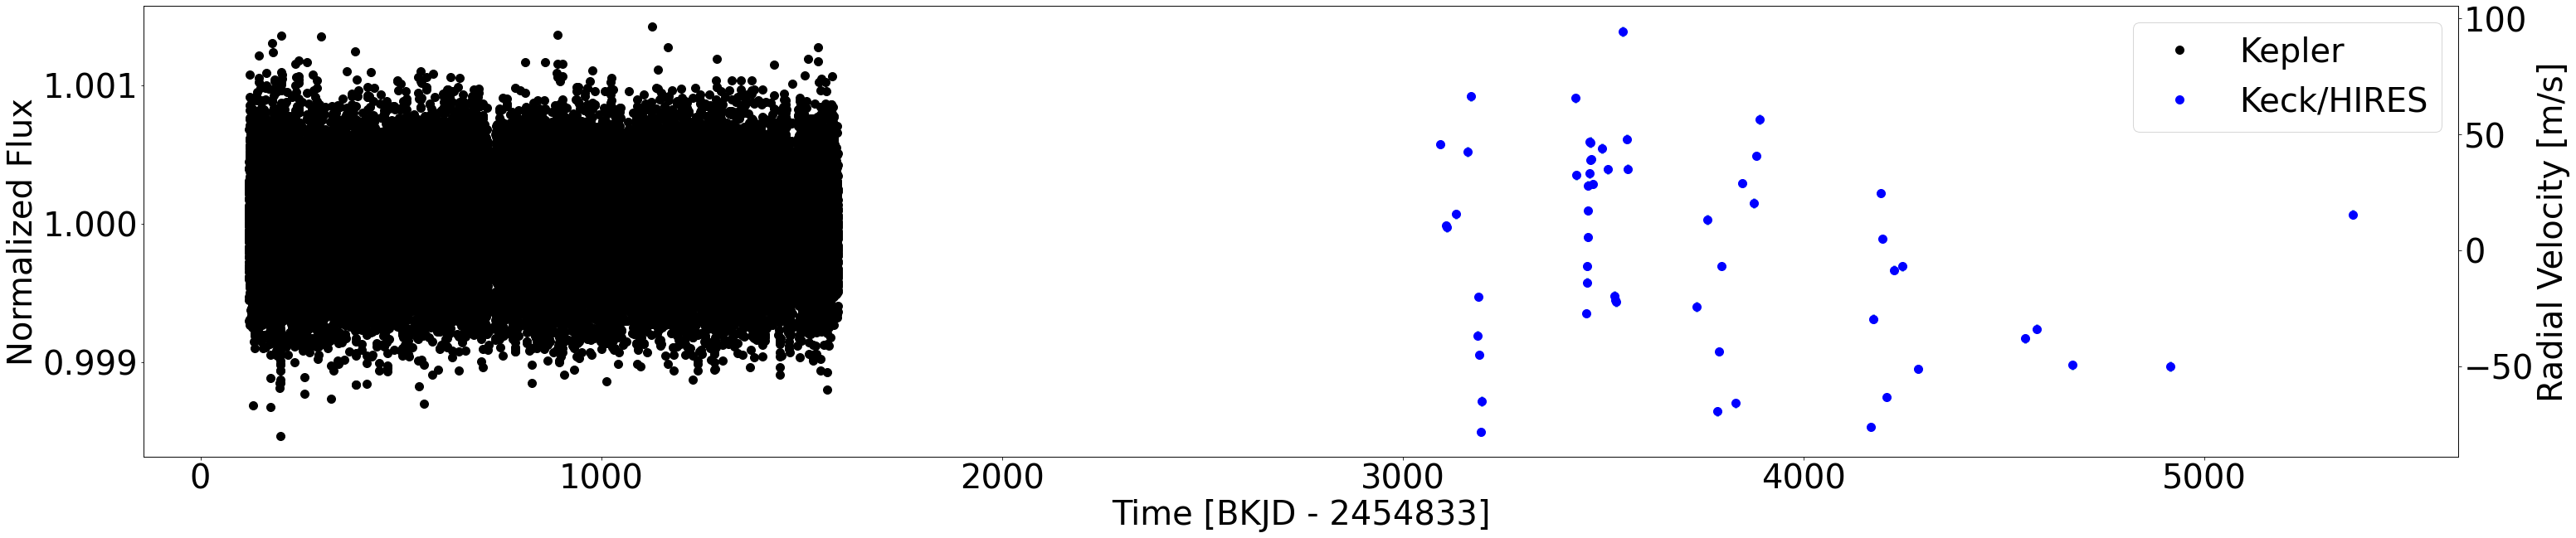

In [1]:
import pandas as pd, numpy as np, lightkurve as lk, exoplanet as xo, astropy.units as u, multiprocessing as mp
import matplotlib.pyplot as plt, matplotlib.pylab as pylab, matplotlib.gridspec as gridspec
import arviz as az, pickle, corner, csv
import pymc3 as pm, pymc3_ext as pmx, aesara_theano_fallback.tensor as tt

from astropy.io import fits
from scipy import signal
from sinusoid import SinusoidModel
from astropy.timeseries import LombScargle
from astropy.table import Table
from functions import * # <-- self-defined functions
from IPython.display import display, Math
from celerite2.theano import terms, GaussianProcess
from PIL import Image

#import data file
lcfs = lk.search_lightcurve("KIC 9145861", author="Kepler").download_all()

lc = lcfs.stitch().remove_nans().remove_outliers().normalize() # type: ignore

time = np.ascontiguousarray(lc.time.value, dtype=np.float64)
flux = np.ascontiguousarray(lc.flux, dtype=np.float64)
flux_err = np.ascontiguousarray(lc.flux_err,dtype=np.float64)
texp = 29.7 / (60 * 24) # exposure time in days
#time=0 in BJD_TDB
BJD = time+2454833

#RV Data
dat = pd.read_csv('k06194_rv_mod.csv')
dat.dropna(inplace=True)
rv = np.ascontiguousarray(dat.mnvel, dtype=np.float64) # rv in m/s
rv_err = np.ascontiguousarray(dat.errvel, dtype=np.float64) # rv errors in m/s
t = np.ascontiguousarray(dat.bjd,dtype=np.float64) # time in BJD
s = np.ascontiguousarray(dat.svalue,dtype=np.float64)
t_BKJD = t - 2454833 # converting BJD into BKJD
inst_names = ["hires"]
num_inst = len(inst_names)

plot_og_data(time, flux, t_BKJD, rv, rv_err)

Pre-whitening Algorithm

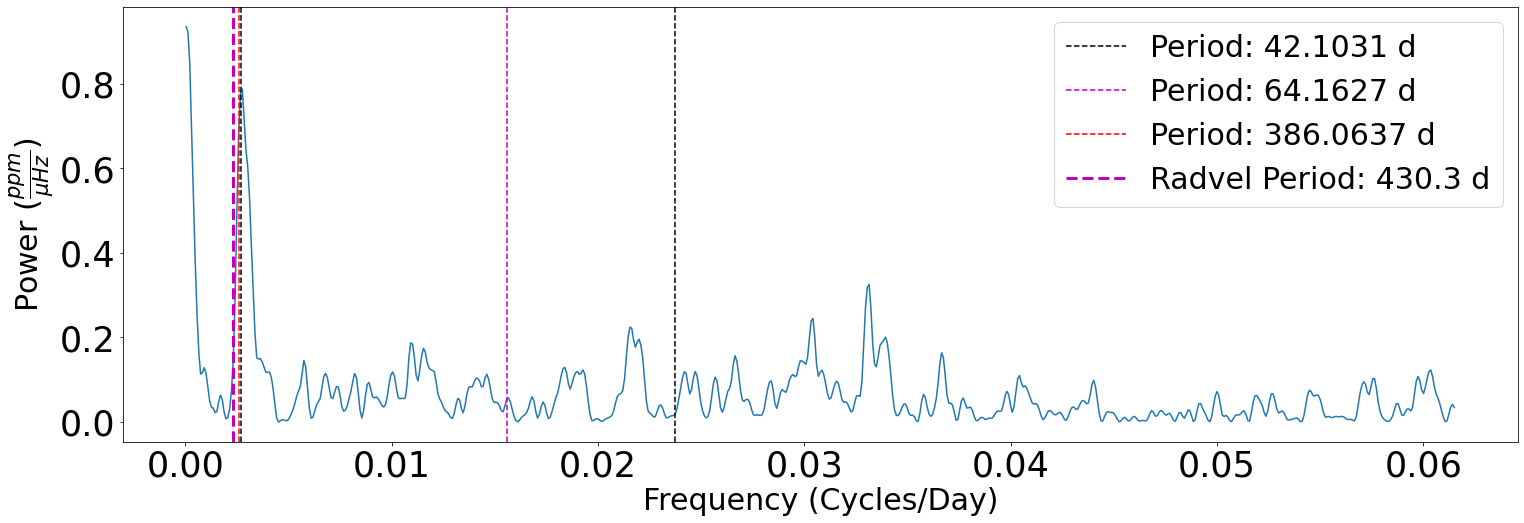

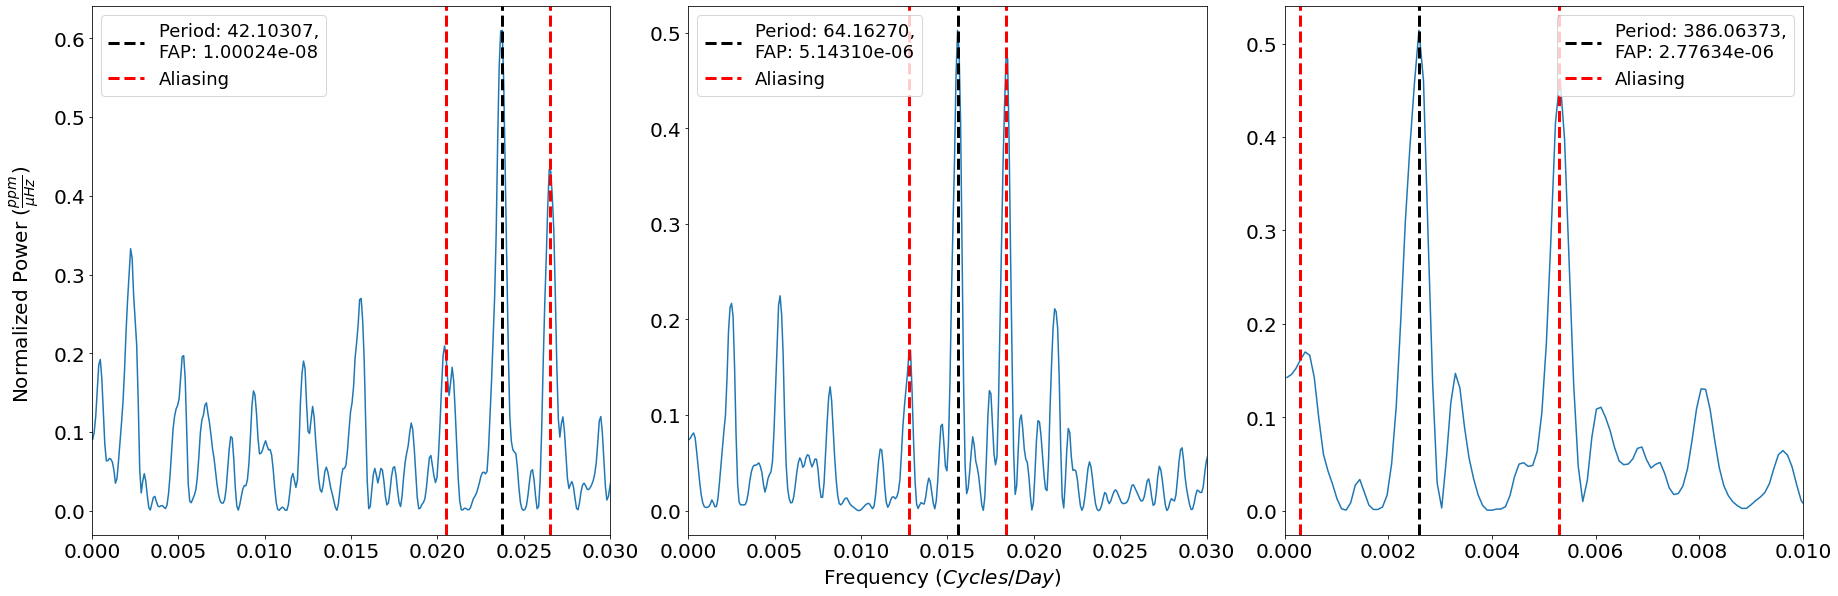

In [2]:
#done in more detail in s-value.ipynb
#frequency limits
f_max = 1/10 #cycles/day, corresponding to a period of 10 days
f_min = 1/1000 #cycles/day, corresponding to a period of 1000 days
frequency = np.linspace(f_min,f_max,num=600)

#Note, when calculating periodogram convert frequencies to angular frequencies
ls_b = LombScargle(t,rv, normalization='standard',fit_mean=True)
freq_b, power_b = ls_b.autopower(method='slow')
planet_b_freq = freq_b[np.argmax(power_b)]

simple_b = SinusoidModel()
simple_b.frequencies = [planet_b_freq]
simple_b.modes = [[1],[2],[3]]
#fitting model to data
simple_b.fit_to_data(t,rv)
#overplotting data on first fit
fit_magnitudes = simple_b(t)
#removing model from data
residual = rv - simple_b(t)

#periodogram for planet c
ls_c = LombScargle(t,residual, normalization='standard',fit_mean=True)
freq_c, power_c = ls_c.autopower(method='slow')
planet_c_freq = freq_c[np.argmax(power_c)]

#specifying model
simple_c = SinusoidModel()
simple_c.frequencies = [planet_c_freq]
simple_c.modes = [[1],[2],[3]]
#fitting model to data
simple_c.fit_to_data(t,rv)
#overplotting data on first fit
fit_magnitudes_c = simple_c(t)
#removing model from data
residual_c = residual - simple_c(t)

#periodogram for planet d
ls_d = LombScargle(t,residual_c, normalization='standard',fit_mean=True)
freq_d, power_d = ls_d.autopower(method='slow')
planet_d_freq = freq_d[np.argmax(power_d)]
#specifying model
simple_d = SinusoidModel()
simple_d.frequencies = [planet_d_freq]
simple_d.modes = [[1],[2],[3]]
#fitting model to data
simple_d.fit_to_data(t,rv)
#overplotting data on first fit
fit_magnitudes_d = simple_d(t)

false_b = ls_b.false_alarm_probability(power_b.max(),method="baluev")
false_c = ls_c.false_alarm_probability(power_c.max(),method="baluev")
false_d = ls_d.false_alarm_probability(power_d.max(),method="baluev")

ls_s = LombScargle(t,s, normalization='standard',fit_mean=False,center_data=False)
freq_s, power_s = ls_s.autopower(method='slow')
max_freq = freq_s[np.argmax(power_s)]

fig, axes = plt.subplots(figsize=(25,8),sharex=False)

labelsize = 20
fontsize=18

ax = axes
ax.plot(freq_s,power_s)
ax.axvline(planet_b_freq, color='k',label='Period: {:.4f} d'.format(1/planet_b_freq), linestyle='--')
ax.axvline(0.0027, color='k',linestyle='--')
ax.axvline(planet_c_freq, color='m',label='Period: {:.4f} d'.format(1/planet_c_freq), linestyle='--')
ax.axvline(planet_d_freq, color='r',label='Period: {:.4f} d'.format(1/planet_d_freq), linestyle='--')
ax.axvline(1/430.3, c='m',linestyle='--',linewidth=3.0,label='Radvel Period: 430.3 d')
ax.tick_params(axis='both', which='major', labelsize=35)
ax.set_xlabel('Frequency (Cycles/Day)',fontsize=30)
ax.legend(loc='upper right',fontsize=30)
ax.set_ylabel(r'Power $(\frac{ppm}{\mu Hz}$)',fontsize=30)
fig.savefig('S-index.png',dpi=100,facecolor='w',bbox_inches='tight')

fig_whiten, axes = plt.subplots(1,3, figsize=(25,8),sharex=False)
ax = axes[0]
ax.plot(freq_b,power_b)
ax.axvline(planet_b_freq, color='black',linewidth=3.0,label='Period: {0:.5f},\nFAP: {1:.5e}'.format(1/planet_b_freq,false_b), linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=labelsize)
ax.axvline(0.0205, c='r',linestyle='--',linewidth=3.0,label='Aliasing')
ax.axvline(0.0265, c='r',linestyle='--',linewidth=3.0)
ax.legend(loc='upper left',fontsize=fontsize)
ax.set_xlim(0,0.03)

ax = axes[1]
ax.plot(freq_c,power_c)
ax.axvline(planet_c_freq, color='black',linewidth=3.0,label='Period: {0:.5f},\nFAP: {1:.5e}'.format(1/planet_c_freq,false_c), linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=labelsize)
ax.axvline(0.0128, c='r',linestyle='--',linewidth=3.0,label='Aliasing')
ax.axvline(0.0184, c='r',linestyle='--',linewidth=3.0)
ax.legend(loc='upper left',fontsize=fontsize)
ax.set_xlim(0,0.03)

ax = axes[2]
ax.plot(freq_d,power_d)
ax.axvline(planet_d_freq, color='black',linewidth=3.0,label='Period: {0:.5f},\nFAP: {1:.5e}'.format(1/planet_d_freq,false_d), linestyle='--')
ax.axvline(0.0003, c='r',linestyle='--',linewidth=3.0,label='Aliasing')
ax.axvline(0.0053, c='r',linestyle='--',linewidth=3.0)
ax.legend(loc='upper right',fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=labelsize)
ax.set_xlim(0,0.01)

fig_whiten.text(0.5, -0.01, r'Frequency $(Cycles/Day)$', ha='center', va='center', fontsize=labelsize)
fig_whiten.text(-0.01, 0.5, r'Normalized Power $(\frac{ppm}{\mu Hz}$)', ha='center', va='center', rotation='vertical',fontsize=labelsize)
plt.tight_layout()
fig_whiten.savefig('Pre-whitening.png',dpi=100,facecolor='w',bbox_inches='tight')
# fig.savefig('RV_Freq_spectrum.png',dpi=100,facecolor='w')
# fig.savefig('spectrum_comparisons.png', facecolor='w')

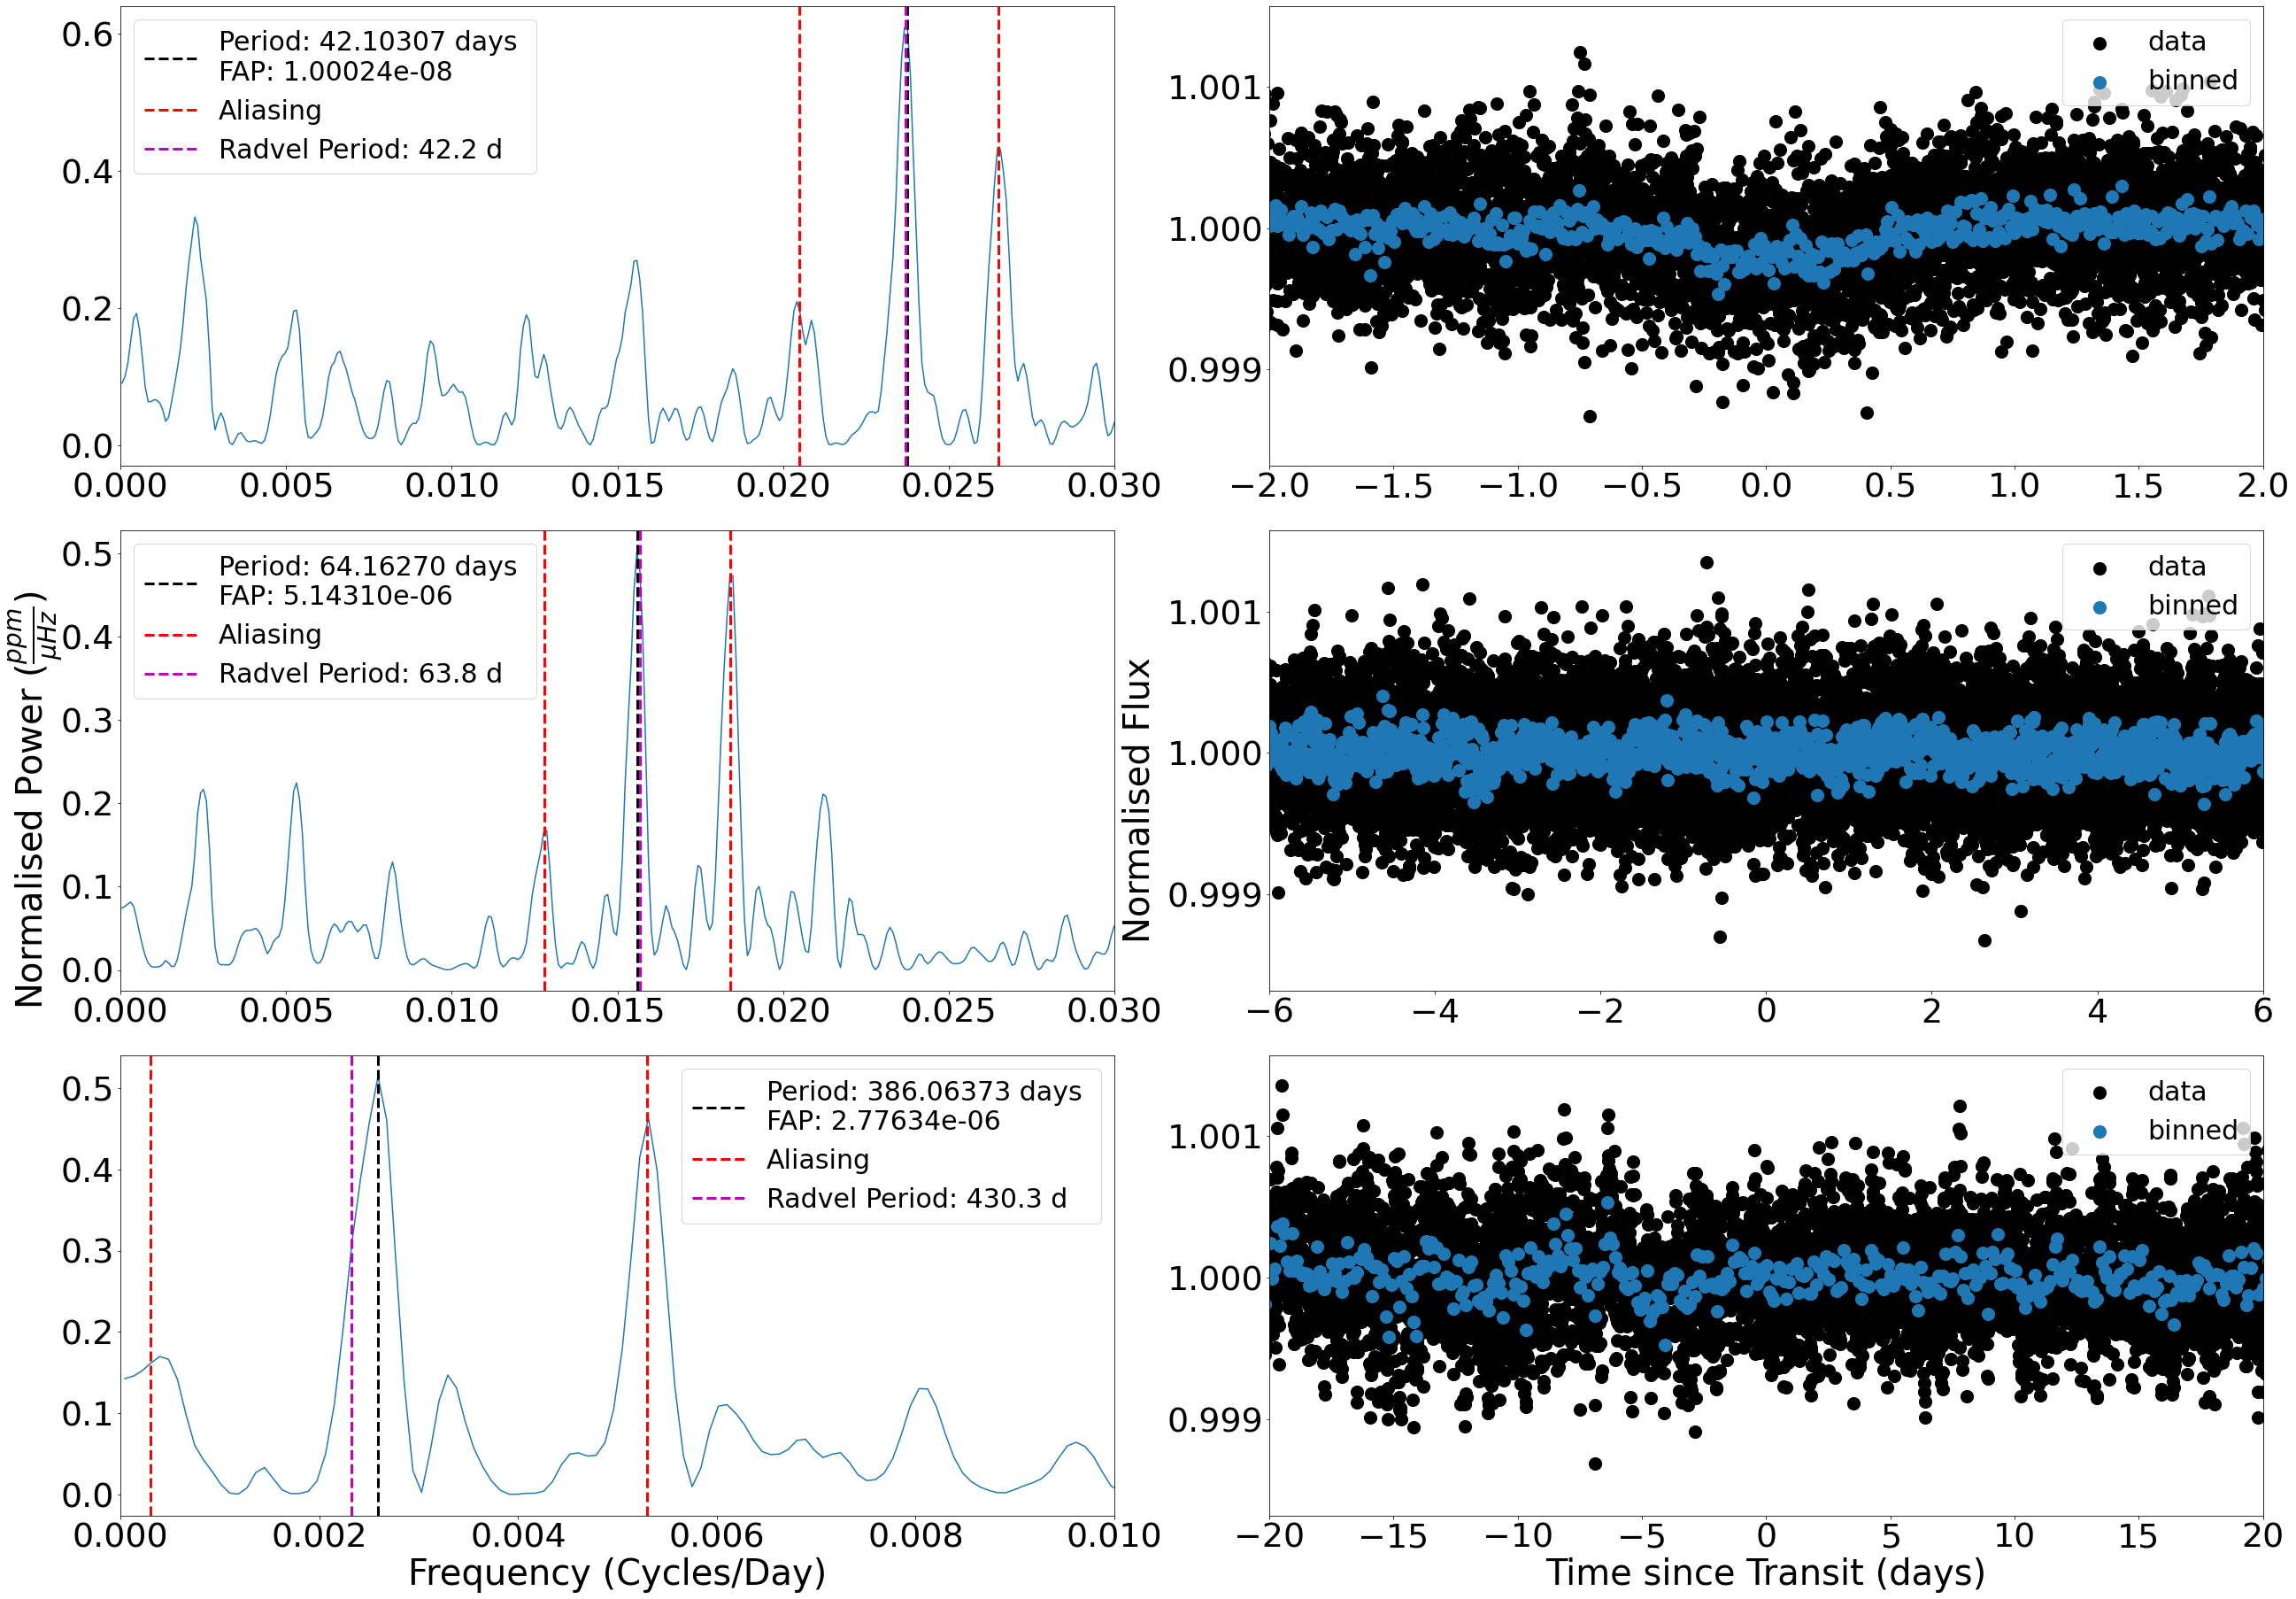

In [3]:
#RV Data
dat = pd.read_csv('k06194_rv_mod.csv')
rv = np.array(dat.mnvel) # rv in m/s
rv_err = np.array(dat.errvel) # rv errors in m/s
t = np.array(dat.bjd) # time in BJD
t_BKJD = t - 2454833 # converting BJD into BKJD
inst_names = ["hires"]
num_inst = len(inst_names)

fontsize=30
titlesize=40
labelsize=38

fig, axes = plt.subplots(3,2, figsize=(35,25),sharex=False)
ax = axes[0,0]
ax.plot(freq_b,power_b)
ax.axvline(planet_b_freq, color='black',label='Period: {0:.5f} days \nFAP: {1:.5e}'.format(1/planet_b_freq,false_b), linestyle='--',linewidth=3.0)
ax.axvline(0.0205, c='r',linestyle='--',linewidth=3.0,label='Aliasing')
ax.axvline(0.0265, c='r',linestyle='--',linewidth=3.0)
ax.axvline(1/42.2, c='m',linestyle='--',linewidth=3.0,label='Radvel Period: 42.2 d')
ax.tick_params(axis='both', which='major', labelsize=labelsize)
ax.legend(loc='upper left', fontsize=fontsize)
ax.set_xlim(0,0.03)

ax = axes[1,0]
ax.plot(freq_c,power_c)
ax.axvline(planet_c_freq, color='black',label='Period: {0:.5f} days \nFAP: {1:.5e}'.format(1/planet_c_freq,false_c), linestyle='--',linewidth=3.0)
ax.axvline(0.0128, c='r',linestyle='--',linewidth=3.0,label='Aliasing')
ax.axvline(0.0184, c='r',linestyle='--',linewidth=3.0)
ax.axvline(1/63.8, c='m',linestyle='--',linewidth=3.0,label='Radvel Period: 63.8 d')
ax.tick_params(axis='both', which='major', labelsize=labelsize)
ax.legend(loc='upper left', fontsize=fontsize)
ax.set_xlim(0,0.03)

ax = axes[2,0]
ax.plot(freq_d,power_d)
ax.axvline(planet_d_freq, color='black',label='Period: {0:.5f} days \nFAP: {1:.5e}'.format(1/planet_d_freq,false_d), linestyle='--',linewidth=3.0)
ax.axvline(0.0003, c='r',linestyle='--',linewidth=3.0,label='Aliasing')
ax.axvline(0.0053, c='r',linestyle='--',linewidth=3.0)
ax.axvline(1/430.3, c='m',linestyle='--',linewidth=3.0,label='Radvel Period: 430.3 d')
ax.set_xlabel('Frequency (Cycles/Day)',fontsize=titlesize)
ax.legend(loc='upper right', fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=labelsize)
ax.set_xlim(0,0.01)

ax = axes[0,1]
t0s_b = 2458350.5 - 2454833 # from radvel converted to BKJD
periods = 42.2960# from Transit fit
p0_b = 1/planet_b_freq
x_fold_b = (time - t0s_b + 0.5 * periods) % periods - 0.5 * periods

binned = lc.fold(period=periods, epoch_time=t0s_b).bin(.008).remove_outliers()
flux_binned = binned.flux
time_binned = binned.time.value
flux_err_binned = binned.flux_err

ax.scatter(x_fold_b,flux,c="k",s=200, label='data',zorder=-1000) 
ax.scatter(time_binned,flux_binned,s=200, label='binned', zorder=2) 
ax.legend(loc='upper right',fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=labelsize)
ax.set_xlim(-2,2)

# plot data within 2 days of transit
days =  2
transit_mask = (
    np.abs(
        (time - t0s_b + 0.5 * periods) % periods - 0.5 * periods
    )
    < days
)
time_cull = time[transit_mask]
flux_cull = flux[transit_mask]
flux_err_cull = flux_err[transit_mask]
x_fold_cull = (time_cull - t0s_b + 0.5 * periods) % periods - 0.5 * periods

ax = axes[1,1]
t0_c = 2458213.9 - 2454833 # t_conj from Radvel, converted to BKJD
p0_c = 1/planet_c_freq
x_fold_c = (time - t0_c + 0.5 * p0_c) % p0_c - 0.5 * p0_c
binned_c = lc.fold(period=p0_c, epoch_time=t0_c).bin(.008).remove_outliers()
flux_binned_c = binned_c.flux
time_binned_c = binned_c.time.value
flux_err_binned_c = binned_c.flux_err

ax.scatter(x_fold_c,flux,c="k",s=200, label='data',zorder=-1000)
ax.scatter(time_binned_c,flux_binned_c,s=200, label='binned', zorder=2) 
ax.legend(fontsize=fontsize,loc='upper right')
ax.set_xlim(-6,6)
ax.tick_params(axis='both', which='major', labelsize=labelsize)

ax = axes[2,1]
t0_d = 2458446.0 - 2454833 # t_conj from Radvel, converted to BKJD
p0_d = 1/planet_d_freq #1/planet_d_freq
x_fold_d = (time - t0_d + 0.5 * p0_d) % p0_d - 0.5 * p0_d
binned_d = lc.fold(period=p0_d, epoch_time=t0_d).bin(.1).remove_outliers()
flux_binned_d = binned_d.flux
time_binned_d = binned_d.time.value
flux_err_binned_d = binned_d.flux_err

ax.scatter(x_fold_d,flux,c="k",s=200, label='data',zorder=-1000)
ax.scatter(time_binned_d,flux_binned_d,s=200, label='binned', zorder=2) 
ax.legend(fontsize=fontsize,loc='upper right')
ax.set_xlim(-20,20)
ax.tick_params(axis='both', which='major', labelsize=labelsize)
ax.set_xlabel('Time since Transit (days)',fontsize=titlesize)

fig.text(-0.01, 0.5, r'Normalised Power ($\frac{ppm}{\mu Hz}$)', ha='center', va='center', rotation='vertical',fontsize=titlesize)
fig.text(0.485, 0.5, 'Normalised Flux', ha='center', va='center', rotation='vertical',fontsize=titlesize)
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=3)
plt.savefig('Planetary Classification.png', facecolor='w',dpi=100,bbox_inches='tight')

Priors for exoplanet (Note that transit priors will be heavily constrained as they are well known from a prior transit-only fit)

In [4]:
# Priors sourced from "KOI-6194 Candidate Records, Exoplanet Archive"
M_J = 317.93842034806 # Mass of Jupiter
# Mass priors from Radvel
M_b = 0.87 * M_J # Mass of first planet
M_c = 0.93 * M_J # Mass of second planet
M_d = 1.34 * M_J # Mass of third planet
M_p = np.array([M_b, M_c,M_d]) #mass of planets in earth mass 
M_p_err = np.array([0.2, 0.5, 0.13]) # mass of planet errors 0.2
t0_radvel = np.array([2458350.5,2458213.9,2458446.0]) # time of conjunction in JD from Radvel
t0s_c = t0_radvel[1]-2454833
t0s_d = t0_radvel[2]-2454833
t0s = np.array([3517.58230672,t0s_c,t0s_d]) # Phase/midpoint reference in KBJD - Transit phase well known
t0s_err = np.array([0.0001,1.1,7.5]) 
periods = np.array([42.29, 63.53, 423.0]) # 42.29602169period in days, both from Transit fit and Radvel - Transit period well known 
periods_errs = np.array([0.0001, 6.3, 42.3]) #period errors
u_star = np.array([0.5890,0.1473]) #Limb Darkening Coeff. (u \in [0,1]) 
R_p = np.array([9.4798,5, 15]) # radius of planet (Earth R), 2nd and 3rd radius assumed - should return these priors in uniform distribution
R_p_err =  np.array([1.8497, 5, 5])

# parameters from asteroseismology
astero = pd.read_csv('Pysyd_results.csv')
Dnu_py = np.array([astero['value'][5], astero['uncertainty'][5]]) 
numax_py = np.array([astero['value'][2], astero['uncertainty'][2]])
MH = [0.36,0.06] # metallicity

# these are from the HIRES spectrograph pipeline
Teff_HIRES = np.array([4725.29,100])
# #from lightkurve documentation
# nu_maxsolar = 3090
# Dnu_solar = 135.1
# T_eff_solar = 5777.2

f_dnu = f_Dnu(Dnu_py[0],numax_py[0],Teff_HIRES[0],MH[0])
display(Math(f"{f_dnu:.3f}"))

rho = DensityRel(Dnu_py[0],f_dnu)
Drho = DensUnc(Dnu_py[0],Dnu_py[1], f_dnu)
Rho_s_dnu = np.array([rho ,Drho]) #using the scaling relation Delta nu \propto \sqrt(\rho_*) 

M_s = np.array([MassRelation(Dnu_py[0],numax_py[0],Teff_HIRES[0],f_dnu), #star mass (solar M)
                MassUnc(Dnu_py[0],Dnu_py[1],numax_py[0],numax_py[1],Teff_HIRES[0],Teff_HIRES[1], f_dnu)])
R_s = np.array([RadRelation(Dnu_py[0],numax_py[0],Teff_HIRES[0],f_dnu), #star radius (solar R)
                RadUnc(Dnu_py[0],Dnu_py[1],numax_py[0],numax_py[1],Teff_HIRES[0],Teff_HIRES[1], f_dnu)])
g_s = np.array([np.log10(GravRelation(numax_py[0],Teff_HIRES[0])*980.665), 
                np.log10(GravUnc(numax_py[0],numax_py[1],Teff_HIRES[0],Teff_HIRES[1])*980.665)])

M_result = r"M_* = ({0:.4f}  \pm {2:.4f}) M_{1}".format(M_s[0],r"\odot",M_s[1])
R_result = r"R_* = ({0:.4f} \pm {2:.4f}) R_{1}".format(R_s[0],r"\odot",R_s[1])
g_result = r"g_* = ({0:.4f} \pm {2:.4f}) {1}".format(g_s[0],r'(dex)', g_s[1])

rho_result = r"\rho_* = ({0:.4e} \pm {2:.4e}) \rho_{1}".format(Rho_s_dnu[0],r"{cgs}",Rho_s_dnu[1])
display(Math(M_result), Math(R_result), Math(rho_result), Math(g_result))

R_s_lightkurve = np.array([6.19, 0.6]) 
M_s_lightkurve = np.array([1.53, 0.1]) 

ecc_planet = np.array([0.149,0.2, 0.045]) # eccentricity of planets from Radvel
ecc_err = np.array([0.04,0.05, 0.05]) # eccentricity errors
omega_planet = np.array([-0.56, 2.7, 0.5]) # argument of periasteron from Radvel
omega_planet_err = np.array([0.35, 0.22,1.5]) # argument errors

Ks = xo.estimate_semi_amplitude(periods, t_BKJD, rv, t0s=t0s) # type:ignore
msini = xo.estimate_minimum_mass(periods, t_BKJD, rv, rv_err, t0s=t0s, m_star=M_s[0]) # type: ignore
print("Minimum mass in Jupiter mass:", msini)
msini = msini.to(u.M_earth) # type: ignore
print("Minimum mass in Earth mass:", msini)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Minimum mass in Jupiter mass: [0.73761328 0.70740523 0.98297976] jupiterMass
Minimum mass in Earth mass: [234.43445421 224.8334775  312.41888963] earthMass


Combined Transit and RV Model

In [10]:
# These arrays are used as the times/phases where the models are
# evaluated at higher resolution for plotting purposes
t_rv = np.linspace(t_BKJD.min() - 5, t_BKJD.max() + 5, 2000) # fine grid to calculate RVs over
x_rv_ref = 0.5 * (t_BKJD.min() + t_BKJD.max()) # midpoint of RV timeseries
phase_lc = np.linspace(-0.3, 0.3, 100)

def build_model(mask=None, start=None):
    if mask is None:
        mask = np.ones(len(time_cull), dtype=bool)
    with pm.Model() as model: # type: ignore
        # sampled stellar parameters
        mean = pm.Normal("mean", mu=1, sd=10) # The baseline flux

        #Constraining well-known transit priors
        t0 = pm.Normal("t0", mu=t0s,shape=3, sd=0.0001) # The time of a reference transit for each planet sd=t0s[1],
        log_period = pm.Normal("log_period", mu=tt.log(periods), sd=0.0001,shape=3) # The log period ,sd = periods_errs
        # period = pm.Normal("period", mu=periods, sd=periods_errs,shape=3) # The log period ,sd = periods_errs
        period = pm.Deterministic("period", tt.exp(log_period)) # tracking the period

        # m_pl = pm.Normal("m_pl", mu=msini.value,sd=M_p_err*M_J,shape=3) # sample planet mass
        log_m_pl = pm.Normal("log_m_pl", mu=tt.log(msini.value),sd=2,shape=3) # sample planet mass

        m_pl = pm.Deterministic("m_pl", tt.exp(log_m_pl)) # track planet mass
        u_ql = pm.Normal("u",mu=u_star, sd=0.09, shape=2)
        # u_ql = xo.distributions.QuadLimbDark("u",initval=u_star) # informing exoplanet of quad. Limb Dark.,
        # pm.Deterministic("u", u_ql)
        star = xo.LimbDarkLightCurve(u_ql)
        m_star = pm.Normal("m_star", mu=M_s[0], sd=M_s[1]) # sample mass of star
        rho_star = pm.Normal("rho_star",mu=Rho_s_dnu[0],sd=Rho_s_dnu[1]) # sample stellar density
        r_star = pm.Deterministic("r_star", (m_star/(rho_star/1.4))**(1/3)) # convert rho_star back into SI units from cgs
        b = pm.Uniform("b", upper=1, lower=0,shape=3) # uniform prior on impact parameter since 2 are unknown --> RV planets
        r_pl = pm.Uniform("r_pl", upper=50,lower=1,initval=R_p, shape=3) # uniform prior on radii since 2 are unknown --> RV planets
        r_stellar =  (r_pl * 6378/696000) # type: ignore , convert to solar radii - used later in lightcurve model
        ror = pm.Deterministic("ror", r_stellar/r_star) # track ratio of radii (shoud be solar radii/solar radii)
        
        # Eccentricity & argument of periasteron
        ecs = pmx.UnitDisk("ecs", shape=(2,3),initval=0.01 * np.ones((2,3))) # should be shape=(2,n) where n= # of planets
        ecc = pm.Deterministic("ecc", tt.sum(ecs**2,axis=0)) # type: ignore , bound within [0,1]
        omega = pm.Deterministic("omega", tt.arctan2(ecs[1],ecs[0])) # type: ignore

        # RV jitter & a quadratic RV trend
        jitter = pm.Normal("jitter", mu=tt.log(6.58)) # jitter from Radvel
        trend = pm.Normal("trend", mu=0, sd=10.0 ** -np.arange(3)[::-1], shape=3) # trend of RV measurements

        # Transit jitter
        log_sigma_lc = pm.Normal(
            "log_sigma_lc", mu=np.log(np.std(flux_cull[mask])), sd=10
        )
        log_rho_gp = pm.Normal("log_rho_gp", mu=0, sd=10)
        log_sigma_gp = pm.Normal( # mean amplitude of data
            "log_sigma_gp", mu=tt.log(np.std(flux_cull[mask])), sd=10
        )
        # A jitter term describing excess white noise
        log_jitter = pm.Normal("log_jitter", mu=np.log(np.mean(flux_err_cull[mask])), sigma=2.0)
        
        # Set up a Keplerian orbit for the planets
        orbit = xo.orbits.KeplerianOrbit(
            rho_star=rho_star, # enforce rho_star units, but the default should be g/cm^3?????
            m_star=m_star,
            period=period,
            t0=t0, 
            b=b, 
            m_planet=xo.units.with_unit(m_pl, msini.unit), # type: ignore 
            ecc=ecc, 
            omega=omega
            )
        
        # track the semi-major axis
        a = pm.Deterministic("a", orbit.a)
        # RV drift of HIREs
        means = pm.Normal(
            "means",
            mu=np.array([np.median(rv)]),
            sigma=200,
            shape=num_inst,
        )
        # Compute the RV offset for each data point
        mean_rv = tt.zeros(len(t_BKJD))
        mean_rv += means # type: ignore
        pm.Deterministic("mean_rv", mean_rv) # track this offset for plotting purposes
        K = pm.Deterministic("K",orbit.K0*(m_pl/M_J)) #<--check this

        # Compute the model light curve, noting that r is in solar radii
        light_curves = star.get_light_curve(orbit=orbit, r=r_stellar, t=time_cull)
        light_curve = pm.math.sum(light_curves, axis=-1) + mean # accounts for relative flux offset # type: ignore
        resid = flux_cull[mask] - light_curve[mask]

        # GP model for the light curve
        kernel = terms.SHOTerm(sigma=tt.exp(log_sigma_gp),rho=tt.exp(log_rho_gp), Q=1/np.sqrt(2)) # type: ignore
        # model RV variability, periodicity is measured here for rho
        gp = GaussianProcess(kernel=kernel, t=time_cull[mask],diag=flux_err_cull[mask]**2 + tt.exp(2 * log_jitter),mean=mean) # diag=flux_err_cull[mask]**2 + tt.exp(2 * log_jitter),mean=meantime scale ,yerr=tt.exp(log_sigma_lc)
        # Compute the Gaussian Process likelihood and add it into the
        # the PyMC3 model as a "potential"
        gp.marginal("gp", observed=resid)
        pm.Deterministic("light_curves", light_curves) # Track the value of model light curve for plotting and chi^2 optimization purposes
        pm.Normal("obs_lc", mu=light_curve, sd=flux_err_cull, observed=flux_cull) # The likelihood function of the lightcurve model

        #include RVs in most probable model
        def get_rv_model(x, name=""):
                # First the RVs induced by the planets
                vrad = orbit.get_radial_velocity(x)
                pm.Deterministic("vrad" + name, vrad)
                # Define the background model
                A = np.vander(x - x_rv_ref, 3)
                bkg = pm.Deterministic("bkg" + name, tt.dot(A, trend))
                # Sum over planets and add the background to get the full model for 1 planet, put tt.sum(vrad, axis=-1) in for multiple planets
                return pm.Deterministic("rv_model" + name, tt.sum(vrad, axis=-1)  + bkg) 
        
        # Define the RVs at the observed times
        rv_model = get_rv_model(t_BKJD)
        # Also define the model on a fine grid as computed above (for plotting)
        get_rv_model(t_rv, name="_pred")

        # The likelihood for the RVs
        err = tt.sqrt(rv_err**2 + tt.exp(2 * jitter)) # type: ignore , adding RV errors in quadrature
        pm.Normal("obs_rv", mu=rv_model, sd=err, observed=rv) # track RV model for chi^2 optimization purposes

        # Compute and save the phased light curve models
        pm.Deterministic("lc_pred",tt.stack([star.get_light_curve(orbit=orbit, r=r_stellar, t=time_cull)],axis=-1))

        # Checking MAP model; are Nans present? Is logp = inf? If so reparameterize
        print(model.check_test_point())
        start = model.test_point

        # optimizing with m_star+rho_star
        gp_lc_params = [log_sigma_lc, log_sigma_gp, log_rho_gp,log_jitter]
        # transit_params = [r_pl,t0,log_period,b,m_pl]
        transit_params = [r_pl,t0,period,b,m_pl]
        stellar_params = [r_star]
        rv_params = [jitter, m_pl,ecs,mean_rv]
        map_soln = pmx.optimize(start=start, vars=gp_lc_params)
        map_soln = pmx.optimize(start=map_soln, vars=transit_params)
        map_soln = pmx.optimize(start=map_soln, vars=rv_params)
        # map_soln = pmx.optimize(start=map_soln, vars=jitter)
 
        map_soln = pmx.optimize(start=map_soln)

        extra_names = ["light_curves", "gp_pred"]
        extra_paras = [light_curves, gp.predict(resid)]

        extras = dict(
                zip(
                    extra_names,
                    pmx.eval_in_model(extra_paras, map_soln),
                )
        )
        # txt, bib = xo.citations.get_citations_for_model()
    return model, map_soln, extras, orbit
model0, map_soln0, extras0, orbit0 = build_model() 


mean                      -3.220000e+00
t0                         2.487000e+01
log_period                 2.487000e+01
log_m_pl                  -4.840000e+00
u                          2.980000e+00
m_star                     2.160000e+00
rho_star                   9.850000e+00
b_interval__              -4.160000e+00
r_pl_interval__           -6.120000e+00
ecs_unitdisk+interval__   -4.160000e+00
jitter                    -9.200000e-01
trend                      4.150000e+00
log_sigma_lc              -3.220000e+00
log_rho_gp                -3.220000e+00
log_sigma_gp              -3.220000e+00
log_jitter                -1.610000e+00
means                     -6.220000e+00
gp                        -1.430559e+09
obs_lc                    -4.843985e+04
obs_rv                    -3.086900e+02
Name: Log-probability of test_point, dtype: float64


optimizing logp for variables: [log_jitter, log_rho_gp, log_sigma_gp, log_sigma_lc]


message: Desired error not necessarily achieved due to precision loss.
logp: -1430607475.5877604 -> -7616.532747261234
optimizing logp for variables: [log_m_pl, b, log_period, t0, r_pl]


message: Desired error not necessarily achieved due to precision loss.
logp: -7616.5327472613 -> 4236.5052350149845
optimizing logp for variables: [means, ecs, log_m_pl, jitter]


message: Desired error not necessarily achieved due to precision loss.
logp: 4236.5052350149845 -> 4324.511099338271
optimizing logp for variables: [means, log_jitter, log_sigma_gp, log_rho_gp, log_sigma_lc, trend, jitter, ecs, r_pl, b, rho_star, m_star, u, log_m_pl, log_period, t0, mean]


message: Desired error not necessarily achieved due to precision loss.
logp: 4324.511099338271 -> 4622.330577781845


In [11]:
import numpy as np
import pandas as pd
import pymc3 as pm

with model0:
    prior = pm.sample_prior_predictive(
        samples=50_000,
        var_names=["u"],     # physical limb-darkening coeffs (u1,u2)
        random_seed=None,
    )

u_samps = prior["u"]           # shape (N, 2)
labels = ["u1", "u2"]

rows = []
for i, lab in enumerate(labels):
    x = u_samps[:, i]
    p16, p50, p84 = np.percentile(x, [16, 50, 84])
    rows.append(
        {
            "parameter": lab,
            "init": u_star[i],
            "median": p50,
            "err_minus": p50 - p16,
            "err_plus": p84 - p50,
            "p16": p16,
            "p84": p84,
        }
    )

df_ld_prior = pd.DataFrame(rows).set_index("parameter")

# optional: nicer printing
df_ld_prior = df_ld_prior.round(4)

print(df_ld_prior)

             init  median  err_minus  err_plus     p16     p84
parameter                                                     
u1         0.5890  0.5897     0.0902    0.0879  0.4995  0.6776
u2         0.1473  0.1470     0.0893    0.0897  0.0577  0.2367


Checking GP Removal

/home/jvel0761/miniconda3/envs/exoplanet_lightkurve/lib/python3.7/site-packages/ipykernel_launcher.py:2: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  


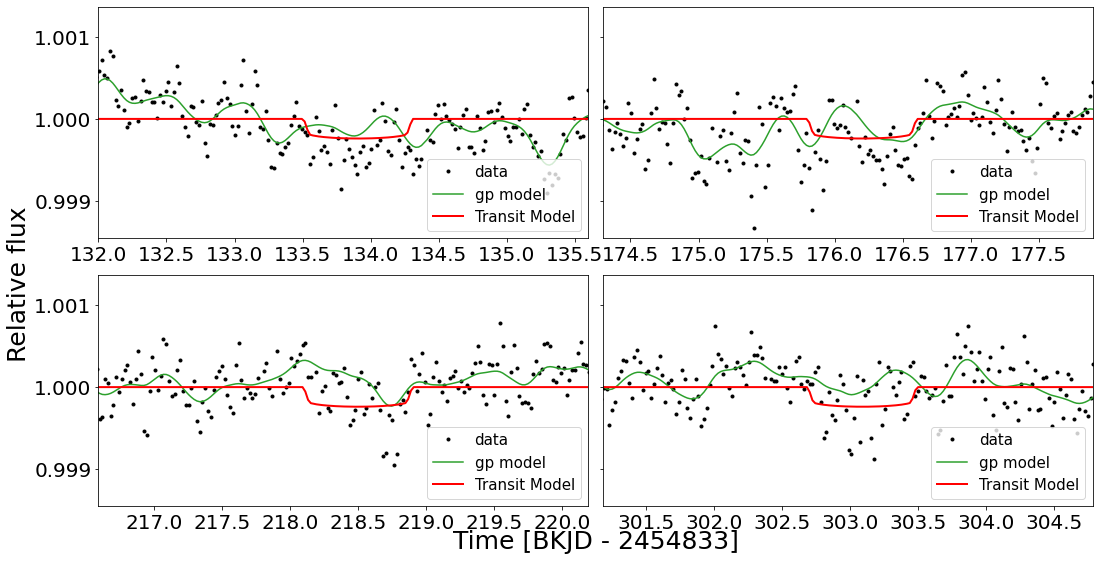

In [12]:
data_arr = np.array([time_cull, flux_cull, flux_err_cull])
rv_dat_arr = np.array([t_rv, t_BKJD, rv, rv_err])
GaussianChecking(data_arr,132,135.6,4,15,8,None,extras0,map_soln0, True,"ASTERO+GP+Transit_2x2.png")

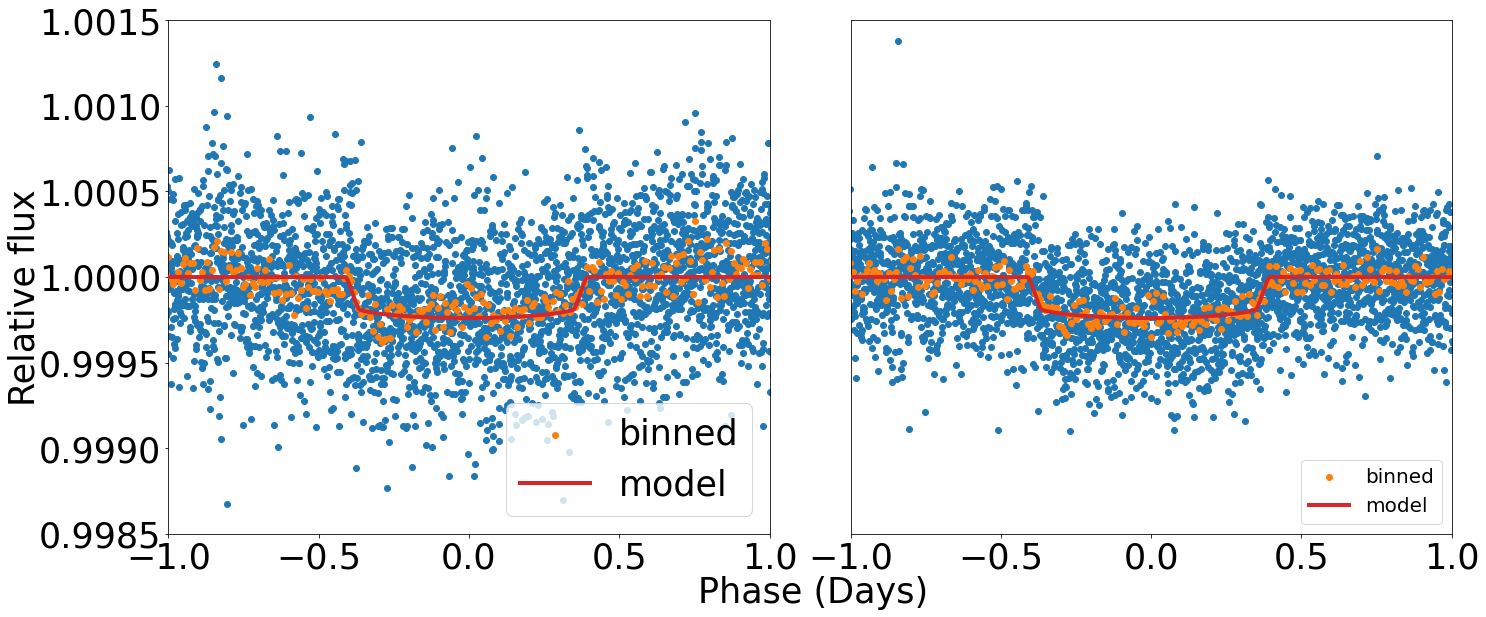

In [13]:
p_map0 = map_soln0["period"][0]# type: ignore 
t0_map0 = map_soln0["t0"][0] # type: ignore 
other_map0 =  map_soln0["light_curves"][:,0]# type: ignore
_ = plot_light_curve(data_arr, lc, days,map_soln0, map_soln0, extras0,save=True)

Checking Transit + RV Models

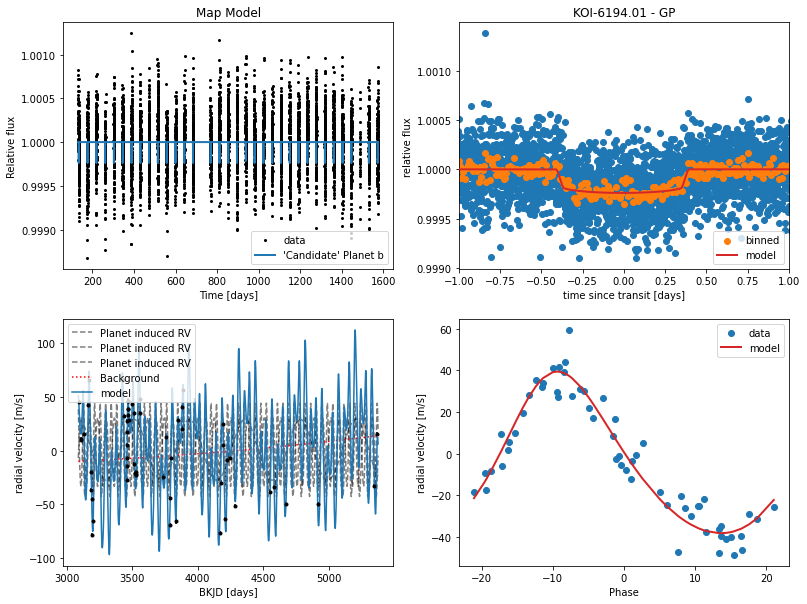

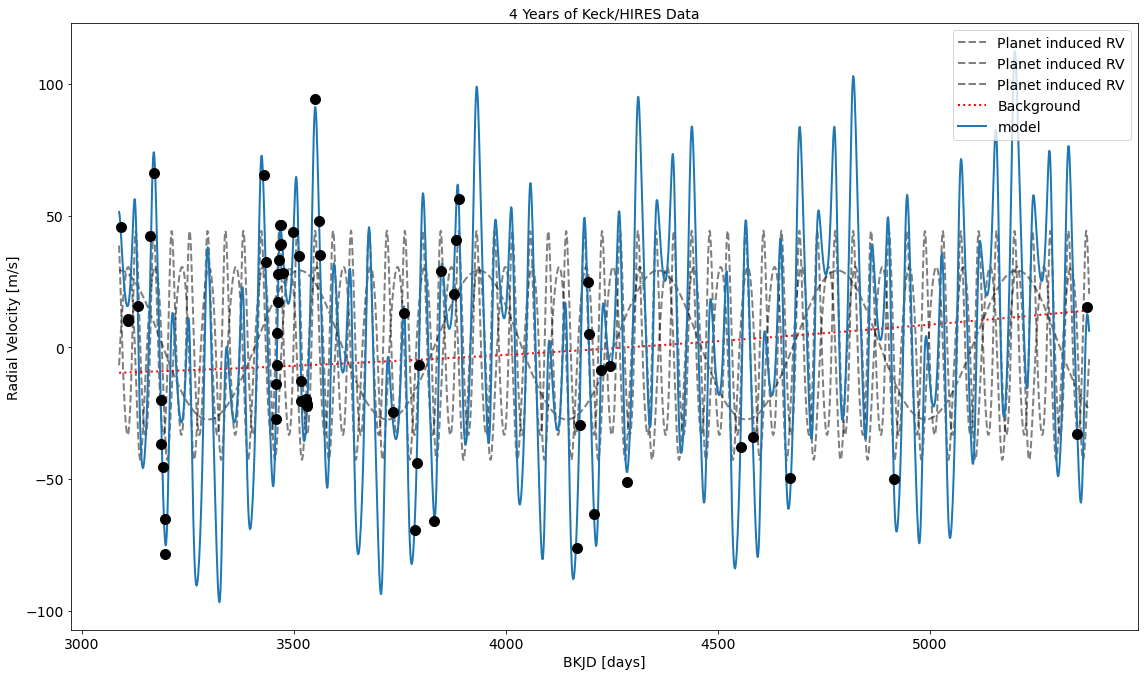

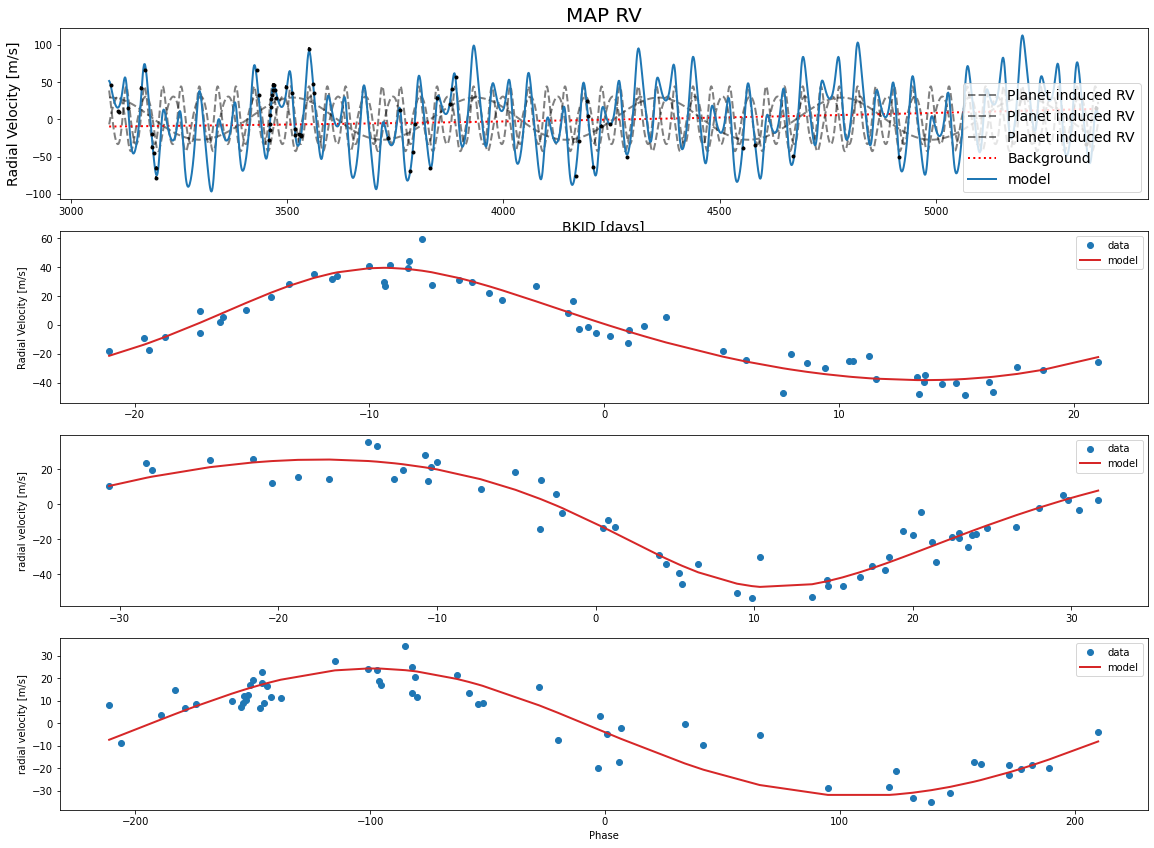

In [14]:
MAPFitting(data_arr,rv_dat_arr,map_soln0,extras0,None)

Sigma Clipping

In [20]:
Sigma = 6.5
mod_1 = (extras0["gp_pred"]+ map_soln0["mean"]+ np.sum(extras0["light_curves"], axis=-1)) # type: ignore
resid_1 = flux_cull - mod_1
rms_1 = np.sqrt(np.median(resid_1**2))
mask_1 = np.abs(resid_1) < Sigma * rms_1

Rebuilding Model

In [21]:
model, map_soln, extras, orbit = build_model(mask_1, map_soln0)

mean                      -3.220000e+00
t0                         2.487000e+01
log_period                 2.487000e+01
log_m_pl                  -4.840000e+00
u                          2.980000e+00
m_star                     2.160000e+00
rho_star                   9.850000e+00
b_interval__              -4.160000e+00
r_pl_interval__           -6.120000e+00
ecs_unitdisk+interval__   -4.160000e+00
jitter                    -9.200000e-01
trend                      4.150000e+00
log_sigma_lc              -3.220000e+00
log_rho_gp                -3.220000e+00
log_sigma_gp              -3.220000e+00
log_jitter                -1.610000e+00
means                     -6.220000e+00
gp                        -1.433709e+09
obs_lc                    -4.843985e+04
obs_rv                    -3.086900e+02
Name: Log-probability of test_point, dtype: float64


optimizing logp for variables: [log_jitter, log_rho_gp, log_sigma_gp, log_sigma_lc]


message: Desired error not necessarily achieved due to precision loss.
logp: -1433757424.6356614 -> -7627.368632266503
optimizing logp for variables: [log_m_pl, b, log_period, t0, r_pl]


message: Desired error not necessarily achieved due to precision loss.
logp: -7627.3686322665535 -> 4226.275742672004
optimizing logp for variables: [means, ecs, log_m_pl, jitter]


message: Desired error not necessarily achieved due to precision loss.
logp: 4226.275742672004 -> 4314.390216380277
optimizing logp for variables: [means, log_jitter, log_sigma_gp, log_rho_gp, log_sigma_lc, trend, jitter, ecs, r_pl, b, rho_star, m_star, u, log_m_pl, log_period, t0, mean]


message: Desired error not necessarily achieved due to precision loss.
logp: 4314.390216380277 -> 4633.83776086614


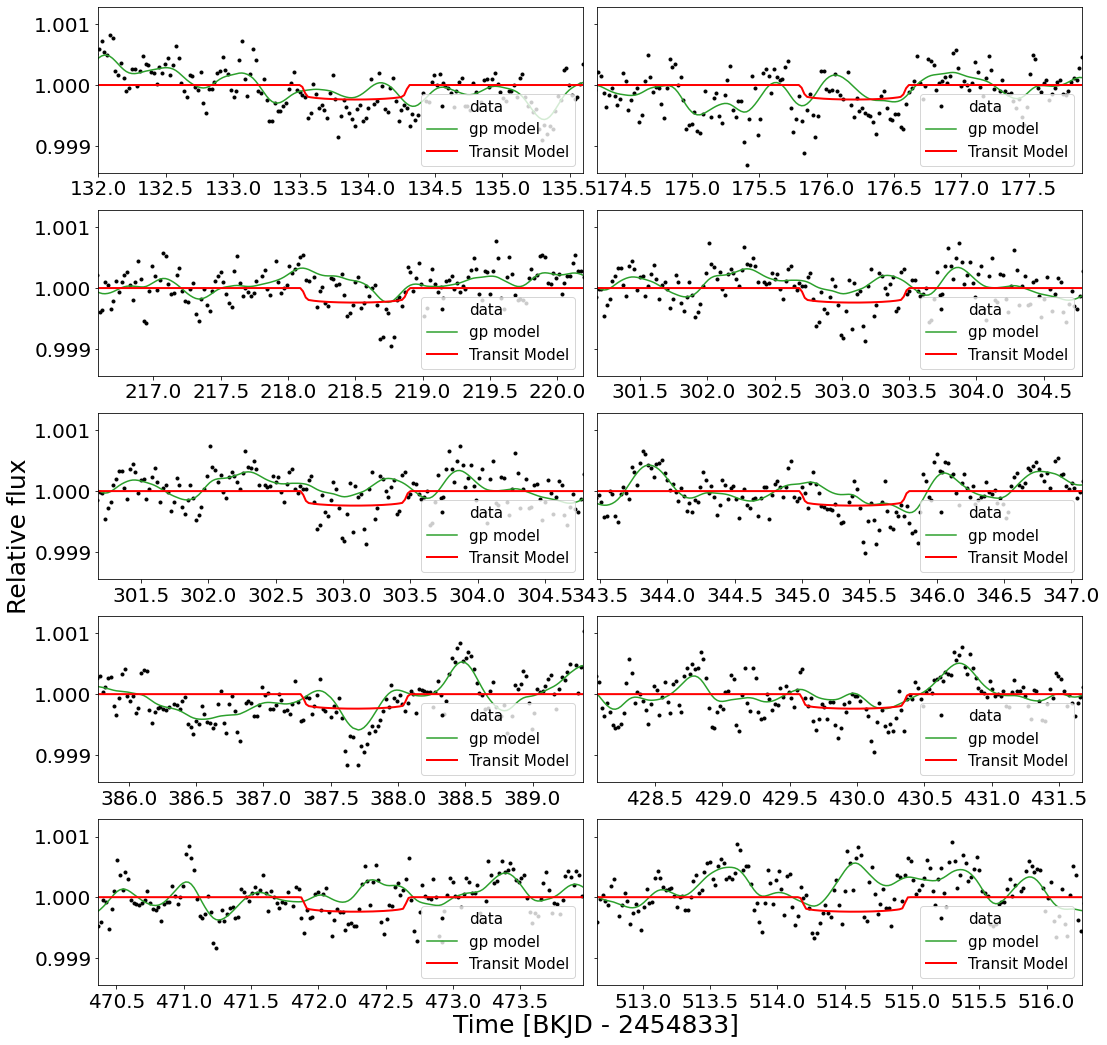

In [22]:
np.savez("exoplanet_model.npz", mask_1,extras,map_soln)

GaussianChecking(data_arr,132,135.6,10,15,15,mask_1,extras,map_soln,True,"Data+Transit+GP.png")

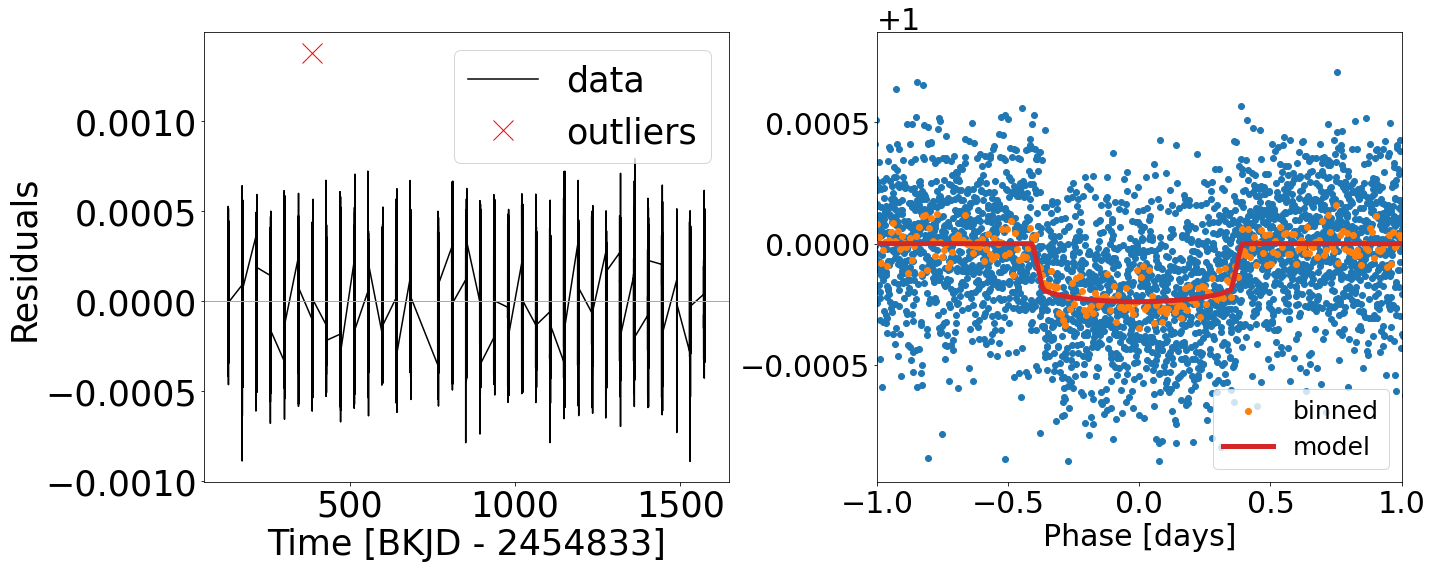

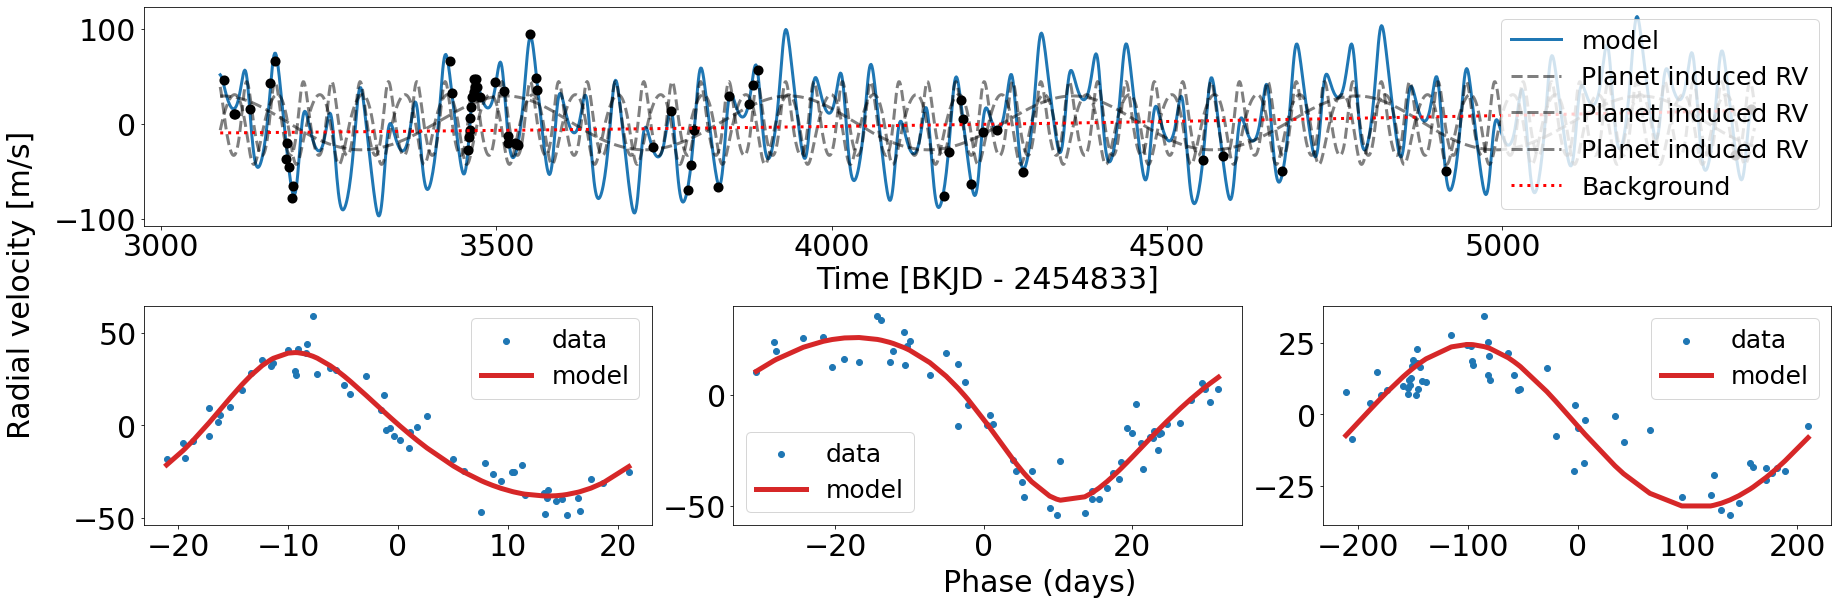

In [23]:
# MAPFitting(map_soln,extras,mask_1)
mask = np.ones(len(time_cull), dtype=bool)
p = map_soln["period"]# type: ignore 
t0 = map_soln["t0"] # type: ignore 

#plotting simulated data against maximum posteriori model
fontsize = 30
legendsize=25
titlesize=20

# Compute the median of posterior estimate of the contribution from
# the other planet. Then we can remove this from the data to plot
# just the planet we care about.
other =  map_soln["light_curves"][:,0]# type: ignore

# this is only for plotting the gp-scaled transit model prior to sigma clipping

fig, axes = plt.subplots(1,2, figsize=(20,8)) # type: ignore

#plotting sigma clipping
ax = axes[0]
ax.plot(time_cull[mask_1], resid_1[mask_1], "k", label="data")
ax.plot(time_cull[~mask_1], resid_1[~mask_1], "xr", label="outliers", markersize=20)
ax.axhline(0, color="#aaaaaa", lw=1)
ax.set_ylabel("Residuals",fontsize=35)
ax.set_xlabel("Time [BKJD - 2454833]",fontsize=35)
ax.tick_params(axis='both',which='major',labelsize=35)
ax.legend(loc='upper right',fontsize=35)

# Plot the folded data
ax = axes[1]
gp_mod = extras["gp_pred"] + map_soln["mean"] # type: ignore
gp_scaled = flux_cull[mask_1]-gp_mod

x_fold= (time_cull - t0[0] + 0.5 * p[0]) % p[0] - 0.5 * p[0]
ax.scatter(x_fold[mask_1], gp_scaled + 1)
#binned data
lcgp = lk.LightCurve(time=time_cull[mask_1], flux=gp_scaled).fold(period=p[0], epoch_time=t0[0]).bin(0.008).remove_outliers() # type: ignore
time_binned = lcgp.time.value
flux_binned = lcgp.flux.value
flux_err_binned = lcgp.flux_err
ax.scatter(time_binned,flux_binned + 1, label='binned', zorder=2)

#plotting folded model
inds = np.argsort(x_fold) #organises the time data in increasing order
inds = inds[np.abs(x_fold)[inds] < 2]
ax.plot(x_fold[inds], (other)[inds] + 1, label="model",zorder=1000,color="C3",lw=5)
ax.legend(fontsize=legendsize, loc=4)
ax.tick_params(axis='both',which='major',labelsize=fontsize)
ax.yaxis.get_offset_text().set_fontsize(fontsize)
ax.set_xlabel("Phase [days]",fontsize=fontsize)
ax.set_xlim(-1, 1)

plt.tight_layout()
fig.savefig('ASTERO+Sigma MAP TransitRV.png', facecolor='w',dpi=100,bbox_inches='tight')

#plotting the RVs only
fig, axes = plt.subplots(2,3,figsize=(25, 8),sharey=False, sharex=False)
axes[0, 0].remove()  
axes[0, 1].remove()
axes[0, 2].remove()

ax = plt.subplot2grid((2, 3), (0, 0), colspan=3)
ax.plot(t_rv, map_soln["rv_model_pred"],linewidth=3.0, label="model",zorder=-10) # type: ignore
ax.scatter(t_BKJD, rv,s=50,c="k",linewidth=3.0,zorder=1)
ax.plot(t_rv, map_soln["vrad_pred"], "--k",linewidth=3.0, label="Planet induced RV",alpha=0.5) # type: ignore # RV induced by planets 
ax.plot(t_rv, map_soln["bkg_pred"], ":r",linewidth=3.0, label="Background")  # type: ignore # RV induced by background sources
ax.legend(fontsize=legendsize, loc='upper right')
ax.set_xlabel("Time [BKJD - 2454833]",fontsize=fontsize)
other1 =  map_soln["vrad"][:,0]# type: ignore
ax.tick_params(axis='both',which='major',labelsize=fontsize)

ax = axes[1,0]
# Plot the folded data
x_fold1= (t_BKJD - t0[0] + 0.5 * p[0]) % p[0] - 0.5 * p[0] # type: ignore
ax.scatter(x_fold1, rv-(map_soln["vrad"][:,1]+map_soln["vrad"][:,2]),label="data") # type: ignore
inds = np.argsort(x_fold1) #organises the time data in increasing order
#plotting folded model
ax.plot(x_fold1[inds], other1[inds]-map_soln["mean_rv"], label="model",zorder=1000,color="C3",lw=5) # type: ignore
ax.tick_params(axis='both',which='major',labelsize=fontsize)
ax.legend(fontsize=legendsize)

ax = axes[1,1]
other2 =  map_soln["vrad"][:,1]# type: ignore
# Plot the folded data
x_fold2= (t_BKJD - t0[1] + 0.5 * p[1]) % p[1] - 0.5 * p[1] # type: ignore
ax.scatter(x_fold2, rv-(map_soln["vrad"][:,0]+map_soln["vrad"][:,2]),label="data") # type: ignore
inds = np.argsort(x_fold2) #organises the time data in increasing order

#plotting folded model
ax.plot(x_fold2[inds], other2[inds]-map_soln["mean_rv"], label="model",zorder=1000,color="C3",lw=5) # type: ignore
ax.tick_params(axis='both',which='major',labelsize=fontsize)
# ax.set_title("KOI-6194c Phase Folded RV",fontsize=titlesize)
ax.legend(fontsize=legendsize)

ax = axes[1,2]
other3 =  map_soln["vrad"][:,2]# type: ignore
# Plot the folded data
x_fold3= (t_BKJD - t0[2] + 0.5 * p[2]) % p[2] - 0.5 * p[2] # type: ignore
ax.scatter(x_fold3, rv-(map_soln["vrad"][:,1]+map_soln["vrad"][:,0]),label="data") # type: ignore
inds = np.argsort(x_fold3) #organises the time data in increasing order
#plotting folded model
ax.plot(x_fold3[inds], other3[inds]-map_soln["mean_rv"], label="model",zorder=1000,color="C3",lw=5) # type: ignore
# ax.set_xlabel('Phase (days)',fontsize=titlesize)
ax.tick_params(axis='both',which='major',labelsize=fontsize)
ax.legend(fontsize=legendsize)
fig.text(-0.02, 0.5, "Radial velocity [m/s]", va='center', rotation='vertical', fontsize=fontsize)
fig.text(0.5, -0.02, "Phase (days)", va='center', rotation='horizontal', fontsize=fontsize)
plt.tight_layout()
fig.savefig('ASTERO+Sigma MAP RV.png', facecolor='w',dpi=100,bbox_inches='tight')

In [ ]:
trace = model_sampling(model, map_soln, 2500, 10000, 1, 2, None)

Auto-assigning NUTS sampler...
Initializing NUTS using adapt_full...
/home/jvel0761/miniconda3/envs/exoplanet_lightkurve/lib/python3.7/site-packages/pymc3/step_methods/hmc/quadpotential.py:510: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")


KeyboardInterrupt: 

In [ ]:
#saves trace for local use
with open('New Caprica Trace Normal u.pkl', 'wb') as buff:
    pickle.dump({'model': model, 'trace': trace}, buff)

# # load saved trace
# with open('New Caprica Trace Normal u.pkl', 'rb') as buff:
#     data = pickle.load(buff)  

# model, trace = data['model'], data['trace']

In [ ]:
summ = az.summary(
    trace,
    # var_names=["trend", "r_star","m_star","t0", "a","period","r_pl","ror","b","m_pl","jitter","ecc","omega","log_sigma_gp","log_rho_gp", "K"] 
)
summ.to_csv('Summary_Adj_NC.csv', float_format="%.2f")

/home/jvel0761/miniconda3/envs/exoplanet_lightkurve/lib/python3.7/site-packages/arviz/stats/diagnostics.py:586: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/jvel0761/miniconda3/envs/exoplanet_lightkurve/lib/python3.7/site-packages/arviz/stats/diagnostics.py:586: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/jvel0761/miniconda3/envs/exoplanet_lightkurve/lib/python3.7/site-packages/arviz/stats/diagnostics.py:586: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/jvel0761/miniconda3/envs/exoplanet_lightkurve/lib/python3.7/site-packages/arviz/stats/diagnostics.py:586: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_s

In [ ]:
# Getting traces for the corner plot to circumvent plotting uninformative posteriors 
# only taking the first chain!!
# fig, axes = plt.subplots(1,3,figsize=(30,8))
i = 0
while i < 3:
    m_star_trace = trace.posterior["m_star"][0] 
    r_star_trace = trace.posterior["r_star"][0] 
    u_trace = trace.posterior["u"].values[0] 
    u1_trace = u_trace[:,0] 
    u2_trace = u_trace[:,1]
    ror_trace = trace.posterior["ror"].values[:,:,0][0] 
    b_trace = trace.posterior["b"].values[:,:,0][0] 
    r_pl_trace = trace.posterior["r_pl"].values[:,:,0][0]/10 
    period_trace = trace.posterior["period"].values[:, :, i][0] # posterior period # type: ignore
    t0_trace = trace.posterior["t0"].values[:, :, i][0] # posterior period # type: ignore
    a_trace = (trace.posterior["a"].values[:,:,i][0] * 696000) / (1.495979e+8)
    m_pl_trace = trace.posterior["m_pl"].values[:,:,i][0] / 317.93842034806
    ecc_trace = trace.posterior["ecc"].values[:,:,i][0] 
    omega_trace = trace.posterior["omega"].values[:,:,i][0] 
    rv_trace = 203* (m_pl_trace)/(period_trace**(1/3)*(m_star_trace+(9.548E-4)*m_pl_trace)**(2/3)*np.sqrt(1-ecc_trace**2)) 

    if i == 0:
        samples = np.vstack([period_trace,t0_trace,a_trace,m_pl_trace,rv_trace,ecc_trace,omega_trace])
        sample_labels = np.array(["$P_{0}$ (days)".format(i+1),"$t_0$ (BKJD)","$a_{0} (AU)$".format(i+1),"$m_{0} \; (M_{1})$".format('{pl}','J'),
                                  "$RV_{0}$ (m/s)".format(i+1),"$ecc_{0}$".format(i+1),"$\omega_{0} \; (deg)$".format(i+1)])
        samples_star = np.vstack([m_star_trace,r_star_trace, b_trace,r_pl_trace,ror_trace, u1_trace, u2_trace])#
        sample_star_labels = np.array(["$M_* $","$R_* $",
                                       "b","$r_{pl} $","ror","u_1", "u_2"])
        star_units = np.array([r"$M_{\odot}$", r"$R_{\odot}$", r"",r"$R_{J}$", r"", r"", r""])

        figure_star = corner.corner(samples_star.T,
                                    labels=sample_star_labels,
                                    # show_titles=True,
                                    filter_vars='regex',
                                    label_kwargs=dict(fontsize=16),
                                    title_kwargs=dict(fontsize=16),
                                    smooth = 1.0)
        """
        Code to axes the corner plots, remove the titles for each and replace them with just the median and percentile values.
        Basically change M_* = 1.23 ^{+}_{-} M_* to 1.23 ^{+}_{-} M_*...
        """
        # Access axes
        axes = np.array(figure_star.axes).reshape(len(sample_star_labels), len(sample_star_labels))

        # Replace diagonal titles with just numbers
        for l in range(len(sample_star_labels)):
            ax = axes[l, l]
            data = samples_star.T[:, l]
            q16, q50, q84 = np.percentile(data, [16, 50, 84])
            q_minus, q_plus = q50 - q16, q84 - q50

            # Remove the title set by corner
            ax.set_title("")

            # Format only value string
            summary_str = r"${:.2f}_{{-{:.2f}}}^{{+{:.2f}}}$".format(q50, q_minus, q_plus)

            # Plot only the value string manually
            ax.text(0.5, 1.05, summary_str + star_units[l],
                    transform=ax.transAxes,
                    horizontalalignment="center",
                    fontsize=16)

        figure_star.savefig('corner_star.png',dpi=100, facecolor='w',bbox_inches='tight')
        plt.close(figure_star)
    else:
        samples = np.vstack([period_trace,t0_trace,a_trace,m_pl_trace,rv_trace,ecc_trace,omega_trace])
        sample_labels = np.array(["$P_{0}$(days)".format(i+1),"$t_0$ (BKJD)","$a_{0}$".format(i+1),"$m_{0}(M_{1})$".format('{pl}','J'),
                                  "$RV_{0}$(m/s)".format(i+1),"ecc_{0}".format(i+1),"$\omega_{0}(deg)$".format(i+1)])
    pl_units = np.array([r" days", r" BKJD", r" AU",r" $M_{J}$", r" m/s", r"", r" deg"])
    figure = corner.corner(samples.T,
                           labels=sample_labels,
                           show_titles=True,
                           filter_vars='regex',
                           label_kwargs=dict(fontsize=13, ),
                           title_kwargs=dict(fontsize=16, pad=5),
                           smooth = 1.0)
    # Offset only bottom and left labels
    for ax in figure.get_axes():
        # Get axis coordinates in grid
        row, col = ax.get_subplotspec().rowspan.start, ax.get_subplotspec().colspan.start
        
        # Offset bottom row (x-labels)
        if row == (samples.T).shape[1] - 1:
            ax.xaxis.labelpad = 50  # increase spacing from ticks
        else:
            ax.set_xlabel("")  # remove middle x-labels

        # Offset left column (y-labels)
        if col == 0:
            ax.yaxis.labelpad = 5
        else:
            ax.set_ylabel("")  # remove duplicate y-labels
    """
    Code to axes the corner plots, remove the titles for each and replace them with just the median and percentile values.
    Basically change M_* = 1.23 ^{+}_{-} M_* to 1.23 ^{+}_{-} M_*...
    """
    # Access axes
    axes = np.array(figure.axes).reshape(len(sample_labels), len(sample_labels))

    # Replace diagonal titles with just numbers
    for l in range(len(sample_labels)):
        ax = axes[l, l]
        data = samples.T[:, l]
        q16, q50, q84 = np.percentile(data, [16, 50, 84])
        q_minus, q_plus = q50 - q16, q84 - q50

        # Remove the title set by corner
        ax.set_title("")

        # Format only value string
        summary_pl = r"${:.2f}_{{-{:.2f}}}^{{+{:.2f}}}$".format(q50, q_minus, q_plus)

        # Plot only the value string manually
        ax.text(0.5, 1.05, summary_pl + pl_units[l],
                transform=ax.transAxes,
                horizontalalignment="center",
                fontsize=16)
    figure.savefig('corner_{0}_NC.png'.format(i+1),dpi=100, facecolor='w',bbox_inches='tight')
    
    plt.close(figure)
    i += 1

plt.tight_layout()

<Figure size 432x288 with 0 Axes>

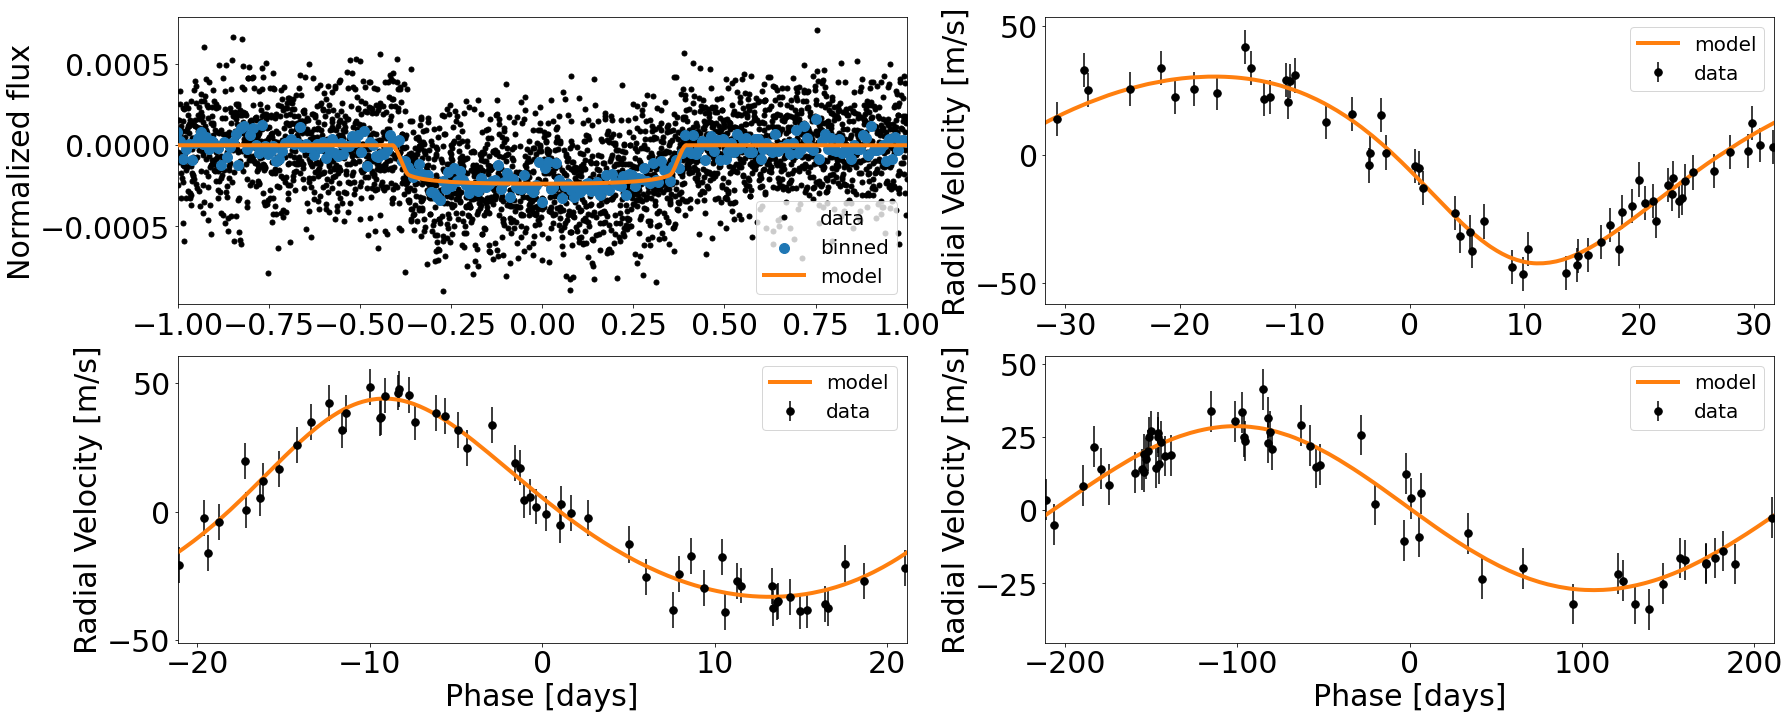

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(25,10), sharex=False, sharey=False) #,gridspec_kw={'hspace': 0.25}
thickness = 4
period_trace = trace.posterior["period"].values[:, :, 0] # posterior period # type: ignore
ror_trace = trace.posterior["ror"].values[:,:,0] # posterior radius ratio # type: ignore
r_pl_trace = trace.posterior["r_pl"].values[:,:,0]/10 # posterior r_pl # type: ignore

p=np.mean(period_trace)
t0=np.mean(trace.posterior["t0"].values[:, :, 0]) # type: ignore
lcs = trace.posterior["light_curves"].values # type: ignore
other = np.median(lcs[:, :, :, 0], axis=(0, 1))
gp_mod = extras["gp_pred"] + map_soln["mean"]
flat_samps = trace.posterior.stack(sample=("chain", "draw")) # type: ignore

ax = axes[0,0]
# Plot the folded data
x_fold= (time_cull[mask_1] - t0 + 0.5 * p) % p- 0.5 * p
m = np.abs(x_fold) < 1.0
ax.plot(
    x_fold[m], (flux_cull[mask_1]-gp_mod)[m],".k", markersize=10,label="data", zorder=-1000
)

# Overplot the phase binned light curve
lcgp = lk.LightCurve(time=time_cull[mask_1], flux=gp_scaled).fold(period=p, epoch_time=t0).bin(0.008).remove_outliers() # type: ignore
flux_binned = lcgp.flux
time_binned = lcgp.time.value
flux_err_binned = lcgp.flux_err
ax.scatter(time_binned,flux_binned, zorder=2, s=100,label="binned")

# Plot the folded model
inds = np.argsort(x_fold)
inds = inds[np.abs(x_fold)[inds] < 10]
pred = np.percentile(flat_samps["lc_pred"][:,0,:], [16, 50, 84], axis=-1)
ax.plot(x_fold[inds], (pred[1][mask_1])[inds], c="C1", label="model",lw=thickness,zorder=1000)

# Annotate the plot with the planet's period
txt_1 = "p = {0:.4f} $\pm$ {1:.4f} d".format(
    np.mean(period_trace), np.std(period_trace)
)
# Annotate the plot with ror
txt_2 = "ror = {0:.4f} $\pm$ {1:.4f}".format(
    np.mean(ror_trace), np.std(ror_trace)
)
# Annotate the plot with r_pl
txt_3 = "$r_{{pl}}$ = {0:.4f} $\pm$ {1:.4f} $R_J$".format(
    np.mean(r_pl_trace), np.std(r_pl_trace)
)

Transit_text = '''{0}
{1}'''.format(txt_1,txt_3)
# Annotate(Transit_text,5,5,20)

ax.legend(fontsize=20, loc=4)
ax.set_ylabel("Normalized flux",fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize) 
ax.set_xlim(-1, 1)

#Plotting RVs
j = 0
for n, letter in enumerate("bcd"):
    vrad_model = []
    period_trace = trace.posterior["period"].values[:, :, n]
    t0_trace = trace.posterior["t0"].values[:, :, n]
    a_trace = trace.posterior["a"].values[:,:,n]

    p = np.mean(period_trace)
    t0 = np.mean(t0_trace)
    ecc_trace = trace.posterior["ecc"].values[:,:,n] # type: ignore
    omega_trace = trace.posterior["omega"].values[:,:,n] # type: ignore
    mass_trace = trace.posterior["m_pl"].values[:,:,n] # posterior mass # type: ignore

    if j > 1:
        j = 1
    ax = axes[(n+1)%2,j]
    
    # Compute the median of posterior estimate of the background RV
    # and the contribution from the other planet. Then we can remove
    # this from the data to plot just the planet we care about.
    other = np.median(flat_samps["vrad"][:,(n + 1)%3], axis=-1)
    other += np.median(flat_samps["bkg"], axis=-1)
    other0 = np.median(flat_samps["vrad"][:,0], axis=-1)
    other1 = np.median(flat_samps["vrad"][:,1], axis=-1)
    other2 = np.median(flat_samps["vrad"][:,2], axis=-1)
    vrad_model.append(other0) # type: ignore
    vrad_model.append(other1) # type: ignore
    vrad_model.append(other2) # type: ignore

    # Annotate the plot with the planet's period
    txt_p = "p = {0:.4f} $\pm$ {1:.4f} d".format(
        np.mean(period_trace), np.std(period_trace)
    )
    # Annotate the RV plot with the mass
    txt_4 = "M = {0:.4f} $\pm$ {1:.4f} $M_J$".format(
        np.mean(mass_trace)/M_J, np.std(mass_trace)/M_J
    )
    # Annotate the RV plot with the Radvial Velocity
    txt_6 = "e = {0:.4f} $\pm$ {1:.4f}".format(
        np.mean(ecc_trace), np.std(ecc_trace)
    )
    # Annotate the RV plot with the Argument of Periasteron
    txt_7 = "a = {0:.4f} $\pm$ {1:.4f}".format(
        np.mean((a_trace * 696000) / (1.495979e+8)), np.std((a_trace* 696000) / (1.495979e+8))
    )

    RV_text = '''{0}
    {1}
    {2}
    {3}'''.format(txt_p,txt_4,txt_6,txt_7)

    # Plot the folded data
    x_fold = (t_BKJD - t0 + 0.5 * p) % p - 0.5 * p
    log_jitter = trace.posterior["jitter"].values[:,n] #type: ignore
    jitter_trace = np.mean(np.exp(log_jitter))
    err = np.sqrt(rv_err**2 + jitter_trace**2)
    ax.errorbar(x_fold, rv - (other + vrad_model[(n-1)%3]), yerr=err, fmt=".k", markersize=15, label="data")

    # Compute the posterior prediction for the folded RV model for this
    # planet
    t_fold = (t_rv - t0 + 0.5 * p) % p- 0.5 * p
    inds = np.argsort(t_fold)
    pred = np.percentile(
        flat_samps["vrad_pred"][:,n][inds], [16, 50, 84], axis=-1
    )
    ax.plot(t_fold[inds], pred[1], c="C1", lw=thickness,label="model")
    ax.tick_params(axis='both', which='major', labelsize=fontsize) 
    # Annotate(RV_text,5,5,20)
    
    ax.set_xlim(-0.5 * p, 0.5 * p)
    ax.legend(fontsize=20, loc="upper right")
    ax.set_ylabel("Radial Velocity [m/s]",fontsize=fontsize)
    if n == 0:
        ax.set_xlabel("Phase [days]",fontsize=fontsize)
    j+=1
ax.set_xlabel("Phase [days]",fontsize=fontsize)
plt.tight_layout()
# fig.savefig('Astero_MCMC TransitRV_NC.png', facecolor='w',dpi=100,bbox_inches='tight')
# plt.close()

In [ ]:


# Constants
R_sun_km = 696000
AU_km = 1.495979e+8
M_J = 317.828  # Earth masses
M_E_to_M_sun = 3.003e-6

# Variables
var_names = ["t0", "period", "r_pl", "a", "ror", "b", "m_pl", "ecc", "omega", "K", "u"]
star_names = ["rho_star", "m_star", "r_star", "log_rho_gp", "log_sigma_gp"]

# Outputs
names, values, up_unc, low_unc = [], [], [], []
skip_u = False
# Loop over planets
for j in range(3):
    # Stellar parameters (only once)
    if j == 0:
        for param in star_names:
            flat = trace.posterior[param].values.flatten()
            p16, p50, p84 = np.percentile(flat, [16, 50, 84])
            dq = np.diff([p16, p50, p84])
            names.append(param)
            values.append(p50)
            low_unc.append(dq[0])
            up_unc.append(dq[1])
            display(Math(rf"\mathrm{{{param}}} = {p50:.4f}_{{-{dq[0]:.4f}}}^{{+{dq[1]:.4f}}}"))

    # Planetary parameters
    for param in var_names:
        if param == "K":
            # Retrieve posterior samples
            m_pl = trace.posterior["m_pl"].values[:, :, j]/317.93842034806  # Jupiter masses
            period = trace.posterior["period"].values[:, :, j]  # days
            ecc = trace.posterior["ecc"].values[:, :, j]
            m_star = trace.posterior["m_star"].values  # Solar masses
            rv_trace =203* (m_pl)/(period**(1/3)*(m_star+(9.548E-4)*m_pl)**(2/3)*np.sqrt(1-ecc**2)) 

            # Compute percentiles
            p16, p50, p84 = np.percentile(rv_trace, [16, 50, 84])
            dq = np.diff([p16, p50, p84])
            names.append(f"K_{j+1}")
            values.append(p50)
            low_unc.append(dq[0])
            up_unc.append(dq[1])
            display(Math(rf"\mathrm{{K}}_{j+1} = {p50:.4f}_{{-{dq[0]:.4f}}}^{{+{dq[1]:.4f}}}"))
        elif param == "u":
            if j > 0:
                continue

            u = trace.posterior["u"].values        # (chain, draw, 2)
            u_flat = u.reshape(-1, u.shape[-1])    # (chain*draw, 2)

            u1 = u_flat[:, 0]
            u2 = u_flat[:, 1]

            mcmc_u1 = np.percentile(u1, [16, 50, 84])
            mcmc_u2 = np.percentile(u2, [16, 50, 84])

            q_u1 = np.diff(mcmc_u1)
            q_u2 = np.diff(mcmc_u2)

            names += ["u_1", "u_2"]
            values += [mcmc_u1[1], mcmc_u2[1]]
            low_unc += [q_u1[0], q_u2[0]]
            up_unc  += [q_u1[1], q_u2[1]]

            display(Math(rf"u_1 = {mcmc_u1[1]:.4f}_{{-{q_u1[0]:.4f}}}^{{+{q_u1[1]:.4f}}}"))
            display(Math(rf"u_2 = {mcmc_u2[1]:.4f}_{{-{q_u2[0]:.4f}}}^{{+{q_u2[1]:.4f}}}"))
        else:
            flat = trace.posterior[param].values[:, :, j]
            p16, p50, p84 = np.percentile(flat, [16, 50, 84])
            dq = np.diff([p16, p50, p84])

            if param == "a":
                # Convert from stellar radii to AU
                p50_au = (p50 * R_sun_km) / AU_km
                dq0_au = (dq[0] * R_sun_km) / AU_km
                dq1_au = (dq[1] * R_sun_km) / AU_km
                names.append(f"{param}_{j+1}")
                values.append(p50_au)
                low_unc.append(dq0_au)
                up_unc.append(dq1_au)
                display(Math(rf"\mathrm{{{param}}}_{j+1} = {p50_au:.4f}_{{-{dq0_au:.4f}}}^{{+{dq1_au:.4f}}}"))
            else:
                names.append(f"{param}_{j+1}")
                values.append(p50)
                low_unc.append(dq[0])
                up_unc.append(dq[1])
                display(Math(rf"\mathrm{{{param}}}_{j+1} = {p50:.4f}_{{-{dq[0]:.4f}}}^{{+{dq[1]:.4f}}}"))

# Save to CSV
filename = "MCMC_Results_NC.csv"
with open(filename, mode="w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Name", "Value", "Up_Unc", "Low_Unc"])
    writer.writerows(zip(names, values, up_unc, low_unc))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>